#AI-Based Financial Risk and Bankruptcy Prediction Decision Support System

#Business Intelligence Project Description and Objectives
##Project Description and Goal

This project focuses on developing an intelligent financial risk analysis and bankruptcy prediction system using Business Intelligence and machine learning techniques. The project uses real financial data collected from Taiwanese companies to analyze financial performance, identify bankruptcy risk patterns, and support financial decision-making.

The analysis is based on important financial indicators related to profitability, leverage, liquidity, company growth, and financial stability. Financial ratios are commonly used to evaluate company performance and detect potential financial distress (Altman, 1968).

Several analytical approaches were applied throughout the project, including exploratory data analysis, statistical testing, machine learning, clustering analysis, and interactive dashboard visualization. Python and Google Colab were used for data preprocessing and predictive modeling, while Microsoft Power BI was used to design interactive dashboards for financial analysis and business insights.

The project mainly focuses on comparing different financial behaviors between high-risk and low-risk companies and evaluating the ability of machine learning models to predict bankruptcy risk accurately. In addition, clustering techniques were used to group companies based on similar financial characteristics.

The final outcome of the project is an interactive financial decision support system that helps users monitor financial risk, understand important financial indicators, and identify companies with higher bankruptcy probability. Business Intelligence systems and predictive analytics are widely used to support data-driven decision-making in financial environments (Power, 2002).

##Project Objectives

The main objectives of this project are:

Analyze financial indicators associated with bankruptcy risk and company financial stability.

Perform exploratory data analysis to understand financial patterns and relationships between variables.

Apply statistical testing methods to compare financial behavior between high-risk and low-risk companies.

Build a bankruptcy prediction model using XGBoost machine learning algorithm.
Develop a deep learning model using MLP Neural Network for performance comparison.

Apply K-Means clustering to segment companies according to financial risk characteristics.

Identify the most important financial features affecting bankruptcy prediction.
Compare model performance using evaluation metrics such as Accuracy, Recall, F1-Score, and ROC-AUC.

Design interactive Power BI dashboards to support financial analysis and business decision-making.

Develop a financial decision support system that combines predictive analytics and Business Intelligence visualization.

#Data Research and Acquiring Effort

The dataset used in this project was obtained from the UCI Machine Learning Repository and is originally based on financial data collected from the Taiwan Economic Journal (TEJ) database.

Dataset Source:
https://archive.ics.uci.edu/dataset/572/taiwanese+bankruptcy+prediction

The dataset focuses on bankruptcy prediction and contains 6,819 company records with 96 financial indicators related to profitability, liquidity, debt structure, operational efficiency, and financial stability. The data was selected because it provides real financial information suitable for machine learning, statistical analysis, clustering, and Business Intelligence visualization.

Several financial datasets were reviewed before selecting the final dataset. However, this dataset was considered the most suitable because it contains real company financial records, a clearly defined bankruptcy label, and a large number of financial variables that support predictive analytics and financial risk analysis.

Although the dataset contains financial records from Taiwanese companies, the selected financial indicators are commonly used in financial analysis worldwide. Therefore, the same methodology used in this project can also be applied to companies from other countries, includng Jordan if similar financial data is available. However, financial behavior patterns and prediction performance may vary depending on economic conditions and financial regulations in each country.

The dataset used in this project is publicly available through the UCI Machine Learning Repository (Dua & Graff, 2019).

#Data Description and Understanding

##Import Libraries

The following libraries are used for data analysis, visualization, and dataset handling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

### Description

Pandas and NumPy are used for handling and analyzing numerical data. Matplotlib and Seaborn are used to create visualizations and charts. The warnings library is used to suppress unnecessary warning messages during execution.

##Upload and Load Dataset

In this step, the dataset is uploaded into Google Colab and loaded into a Pandas DataFrame for analysis.

In [3]:
from google.colab import files
import io

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))

Saving Taiwan Bankruptcy Prediction Dataset (3).csv to Taiwan Bankruptcy Prediction Dataset (3).csv


### Description

The dataset file is uploaded manually using Google Colab upload tools, then read using the read_csv() function and stored in a DataFrame called df.

##Dataset Preview

In [4]:
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,1.256970e-04,0.0,0.458143,0.000725,0.0,0.147950,0.147950,0.147950,0.169141,0.311664,0.017560,0.095921,0.138736,0.022102,0.848195,0.688979,0.688979,0.217535,4.980000e+09,0.000327,0.263100,0.363725,0.002259,0.001208,0.629951,0.021266,0.207576,0.792424,0.005024,0.390284,0.006479,0.095885,0.137757,0.398036,0.086957,0.001814,0.003487,1.820930e-04,1.165010e-04,0.032903,0.034164,0.392913,0.037135,0.672775,0.166673,0.190643,0.004094,0.001997,1.473360e-04,0.147308,0.334015,0.276920,0.001036,0.676269,0.721275,0.339077,0.025592,0.903225,0.002022,0.064856,7.010000e+08,6.550000e+09,0.593831,4.580000e+08,0.671568,0.424206,0.676269,0.339077,0.126549,0.637555,0.458609,0.520382,0.312905,0.118250,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,2.897850e-04,0.0,0.461867,0.000647,0.0,0.182251,0.182251,0.182251,0.208944,0.318137,0.021144,0.093722,0.169918,0.022080,0.848088,0.689693,0.689702,0.217620,6.110000e+09,0.000443,0.264516,0.376709,0.006016,0.004039,0.635172,0.012502,0.171176,0.828824,0.005059,0.376760,0.005835,0.093743,0.168962,0.397725,0.064468,0.001286,0.004917,9.360000e+09,7.190000e+08,0.025484,0.0068

### Description

The head() function displays the first five rows of the dataset.

##Dataset Shape

This step is used to identify the size of the dataset by displaying the total number of rows and columns.

In [5]:
rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 6819
Number of Columns: 96


### Description

The dataset contains 6819 rows and 96 columns, which indicates that the dataset includes a large number of financial records and financial indicators suitable for bankruptcy prediction analysis.

##Dataset Information

This step provides general information about the dataset structure, data types, and the availability of non-null values.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

### Description
The dataset appears to contain complete records with no significant missing values.

##Important Financial Indicators Description

The dataset contains many financial indicators related to company profitability, liquidity, debt structure, operational efficiency, and financial stability.

The following table presents some of the most important financial indicators used in this project.

| Financial Indicator | Description |
|--------------------|-------------|
| ROA(A) before interest and % after tax | Measures company profitability relative to assets. |
| ROA(B) before interest and depreciation after tax | Measures profitability after depreciation effects. |
| ROA(C) before interest and taxes before depreciation | Measures operational profitability before taxes and depreciation. |
| Operating Gross Margin | Indicates operational profitability before expenses. |
| Realized Sales Gross Margin | Measures actual profit generated from sales. |
| Operating Profit Rate | Measures profit generated from operations. |
| Net Profit before Tax | Represents company profit before taxes. |
| Net Income to Total Assets | Measures profitability relative to total assets. |
| Total Asset Growth Rate | Indicates company asset growth over time. |
| Current Ratio | Measures short-term liquidity capability. |
| Quick Ratio | Measures liquidity excluding inventory. |
| Working Capital to Total Assets | Measures short-term financial stability. |
| Cash Flow Rate | Measures cash flow performance efficiency. |
| Cash Flow to Sales | Indicates the relationship between sales and cash flow. |
| Debt Ratio % | Measures the percentage of debt financing. |
| Liability to Equity | Measures liabilities relative to shareholder equity. |
| Total Debt to Total Net Worth | Measures debt relative to net worth. |
| Borrowing Dependency | Indicates dependency on borrowed funds. |
| Retained Earnings to Total Assets | Measures accumulated profitability strength. |
| Inventory Turnover Rate | Measures inventory management efficiency. |

Financial ratios are commonly used to evaluate company performance and bankruptcy risk (Altman, 1968).

#Exploratory Data Analysis (EDA)

Initial exploratory data analysis was conducted to understand the structure, quality, distribution, and financial behavior of the dataset before applying machine learning and deep learning models.

The following analysis steps were performed:

Statistical Summary Analysis

Feature Distribution Analysis

Outlier Analysis

Correlation Analysis

Financial Comparison by Bankruptcy Status

Pivot Table Analysis

Statistical Testing (T-Tests)

These analyses helped identify important financial patterns, relationships, and potential indicators associated with bankruptcy risk.

#Data Primary Cleaning and Transformation

Initial data validation and cleaning procedures were reviewed to assess dataset quality before preprocessing and machine learning analysis.

The dataset was found to be well-structured and clean, with no missing values, duplicate records, or major formatting inconsistencies. Therefore, extensive primary data cleaning and transformation procedures were not required.

Only minimal preprocessing steps, such as data type verification and temporary analytical feature creation, were applied to support exploratory analysis and predictive modeling.

##Missing Values Check


In [7]:
missing_values = df.isnull().sum().sum()

print("Total Missing Values:", missing_values)

Total Missing Values: 0


###Description
A duplicate records check was conducted to ensure that the dataset does not contain repeated company records that may affect analysis accuracy.
###Observation
 No duplicate records were found in the dataset, indicating that the financial
 data is clean and consistent for statistical analysis and predictive modeling

##Duplicate Values Check

In [8]:
df.duplicated().sum()

np.int64(0)

###Description

A duplicate records check was conducted to ensure that the dataset does not contain repeated company records that may affect analysis accuracy.

###Observation

No duplicate records were found in the dataset, indicating that the financial data is clean and consistent for statistical analysis and predictive modeling.

## Selected Financial Indicators

The following financial indicators were selected for the exploratory and statistical analysis because they represent important aspects of financial performance, liquidity, profitability, cash flow, and debt structure.

These indicators are used throughout the analysis to better understand the financial behavior of companies and their relationship with bankruptcy risk.

In [9]:
selected_features = [
    ' ROA(A) before interest and % after tax',
    ' Operating Gross Margin',
    ' Pre-tax net Interest Rate',
    ' Current Ratio',
    ' Quick Ratio',
    ' Cash flow rate',
    ' Cash Flow to Sales',
    ' Debt ratio %',
    ' Liability to Equity',
    ' Retained Earnings to Total Assets'
]

##Statistical Summary

This step provides a statistical overview of the selected financial indicators used in the analysis.

In [10]:
df[selected_features].describe().T

,count,mean,std,min,25%,50%,75%,max
ROA(A) before interest and % after tax,6819.0,5.586249e-01,6.562003e-02,0.0,0.535543,0.559802,0.589157,1.000000e+00
Operating Gross Margin,6819.0,6.079480e-01,1.693381e-02,0.0,0.600445,0.605997,0.613914,1.000000e+00
Pre-tax net Interest Rate,6819.0,7.971898e-01,1.286899e-02,0.0,0.797386,0.797464,0.797579,1.000000e+00
Current Ratio,6819.0,4.032850e+05,3.330216e+07,0.0,0.007555,0.010587,0.016270,2.750000e+09
Quick Ratio,6819.0,8.376595e+06,2.446847e+08,0.0,0.004726,0.007412,0.012249,9.230000e+09
Cash flow rate,6819.0,4.674312e-01,1.703552e-02,0.0,0.461558,0.465080,0.471004,1.000000e+00
Cash Flow to Sales,6819.0,6.715308e-01,9.341346e-03,0.0,0.671565,0.671574,0.671587,1.000000e+00
Debt ratio %,6819.0,1.131771e-01,5.392031e-02,0.0,0.072891,0.111407,0.148804,1.000000e+00
Liability to Equity,6819.0,2.803652e-01,1.446322e-02,0.0,0.276944,0.278778,0.281449,1.000000e+00
Retained Earnings to Total Assets,6819.0,9.347328e-01,2.556422e-02,0.0,0.931097,0.937672,0.944811,1.000000e+00


###Description

Descriptive statistical analysis was performed to examine the behavior and distribution of the selected financial indicators. Statistical measures such as mean, standard deviation, minimum, maximum, and quartiles were calculated to better understand the characteristics of the financial data.

The analysis helps identify variability, concentration patterns, and the presence of extreme values within the dataset before applying machine learning models.

###Observation

The statistical results show noticeable variation across several financial indicators. Some variables, particularly liquidity-related indicators such as Current Ratio and Quick Ratio, contain very large maximum values compared to their average values, indicating the presence of skewed distributions and extreme observations.

In addition, profitability and debt-related indicators show differences in value ranges across companies, reflecting variation in financial performance and risk levels within the dataset.

These findings highlight the importance of preprocessing techniques such as scaling and normalization before model training.

##Bankruptcy Distribution Analysis

This step analyzes the distribution of bankrupt and non-bankrupt companies in the target variable.

In [11]:
df['Bankrupt?'].value_counts()

,count
Bankrupt?,
0,6599
1,220


###Description

This analysis examines the distribution of bankrupt and non-bankrupt companies in the target variable to better understand the balance of the dataset before applying machine learning models.

###Observation

The results show that non-bankrupt companies significantly outnumber bankrupt companies. This indicates that the dataset is imbalanced, which is common in real-world financial datasets.

Such imbalance may affect model learning and prediction performance, making preprocessing techniques and evaluation metrics especially important during model development.

##Bankruptcy Distribution Visualization

Visualizing the target variable helps in understanding the distribution of bankruptcy classes in the dataset.

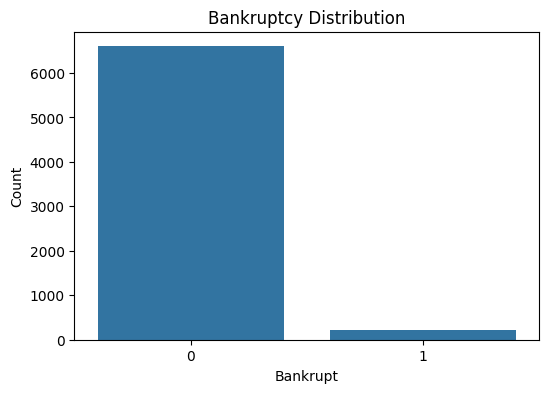

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x='Bankrupt?', data=df)

plt.title('Bankruptcy Distribution')
plt.xlabel('Bankrupt')
plt.ylabel('Count')

plt.show()

###Description

A count plot was created to visualize the number of bankrupt and non-bankrupt companies within the dataset.

###Observation

The visualization confirms that bankrupt companies represent only a small percentage of the total dataset compared to non-bankrupt companies.

This distribution reflects real financial environments where bankruptcy cases occur less frequently than financially stable companies.

##Feature Distribution Analysis

This step explores the distribution of selected financial indicators to better understand data behavior and variability.

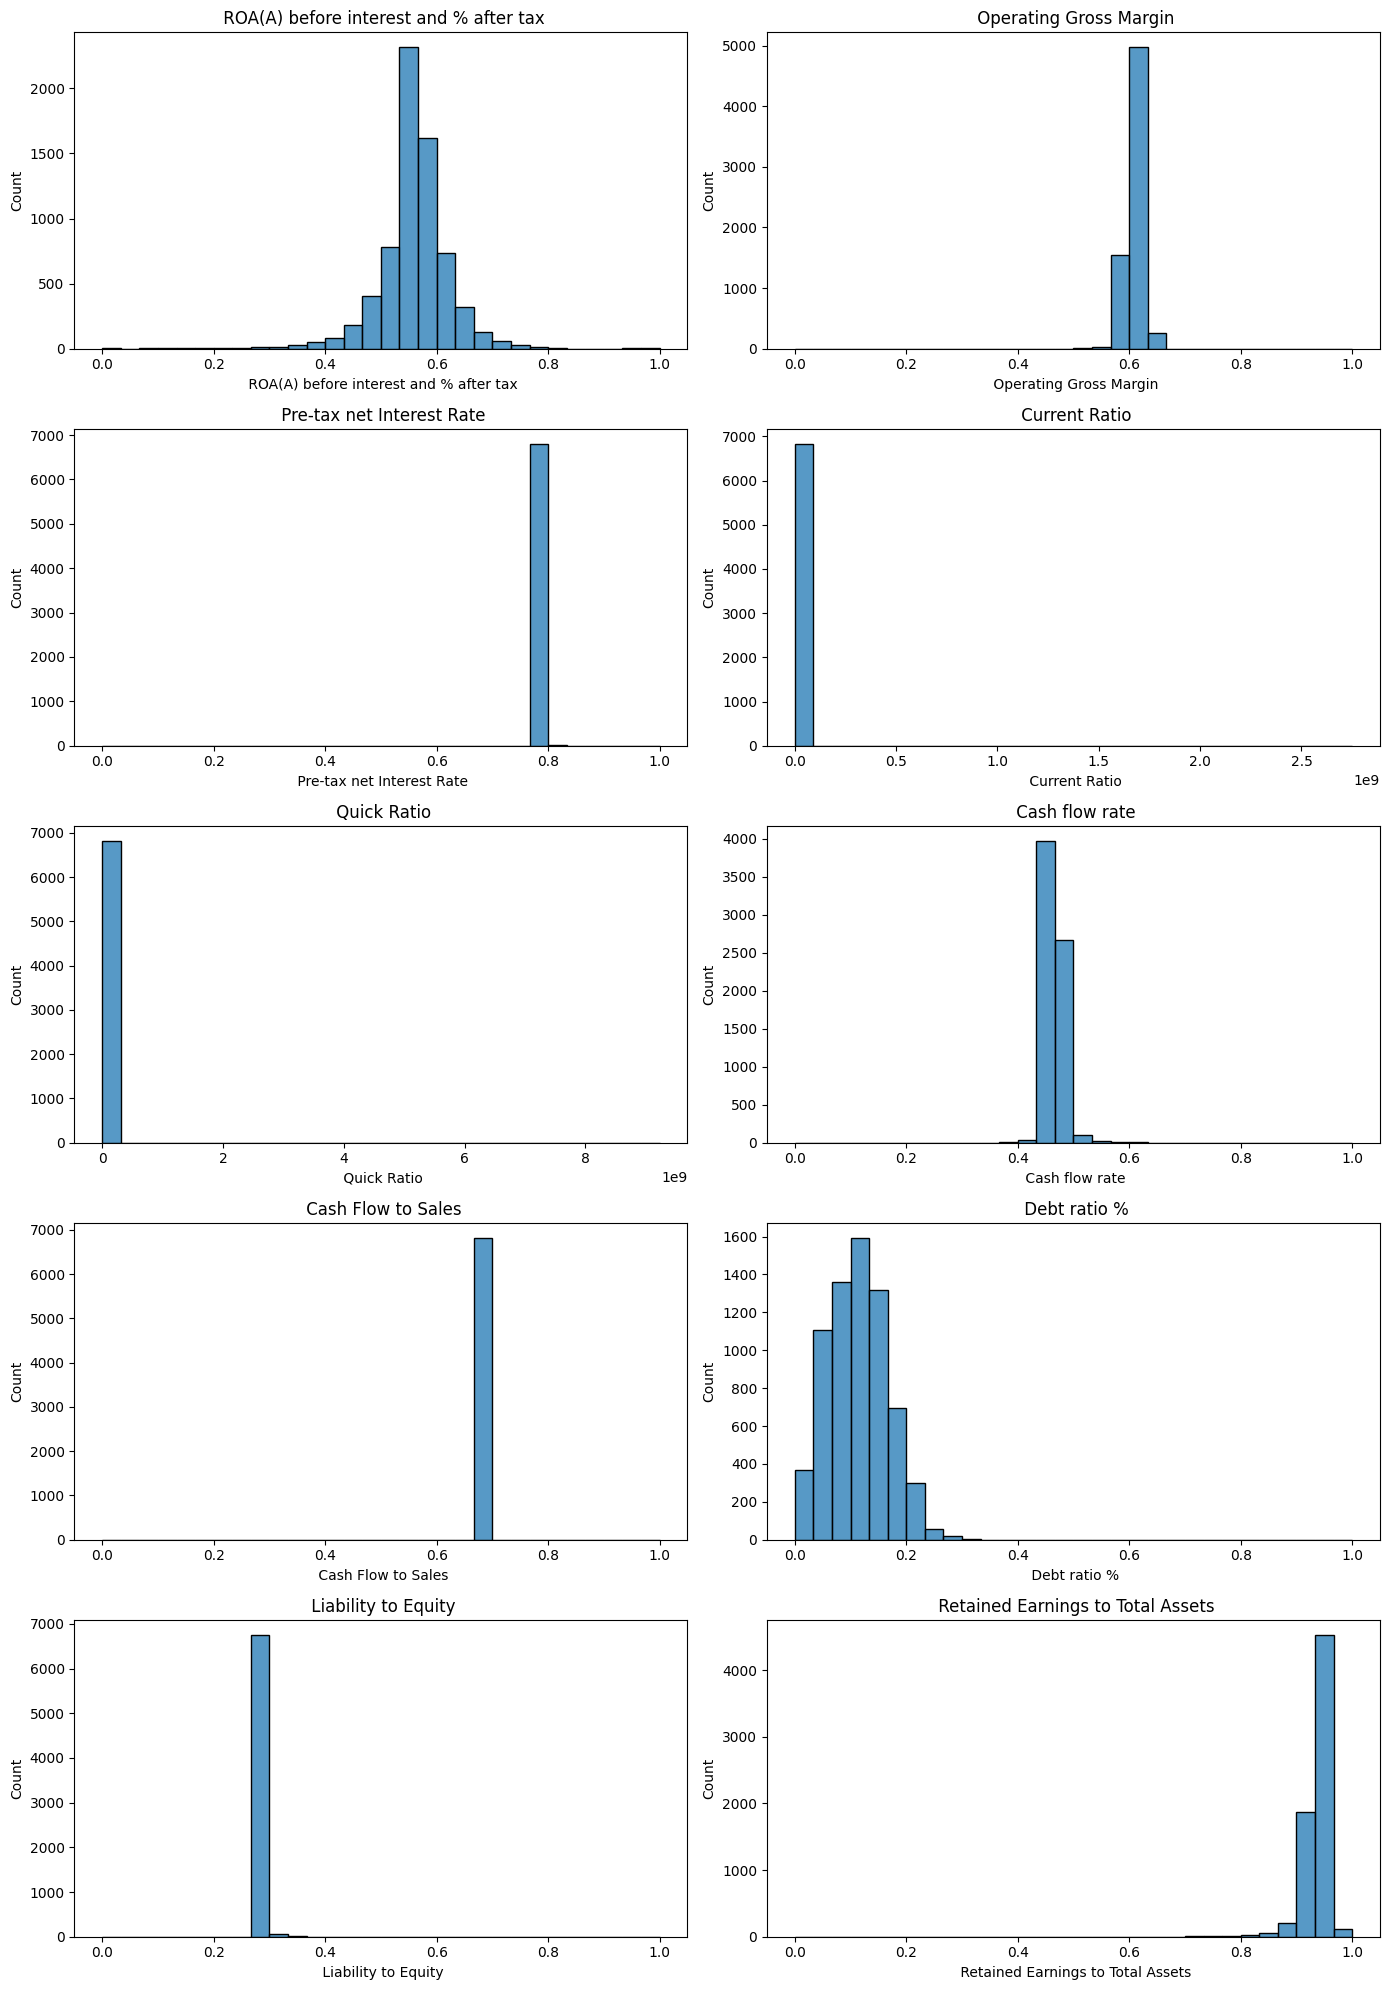

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n = len(selected_features)
cols = 2
rows = math.ceil(n / cols)

plt.figure(figsize=(14, rows * 4))

for i, col in enumerate(selected_features, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[col].dropna(), bins=30, kde=False)
    plt.title(col)

plt.tight_layout()
plt.show()

###Description

Histograms were used to analyze the distribution of selected financial indicators and better understand data concentration, variability, skewness, and potential outliers within the dataset.

The selected variables include profitability indicators, liquidity ratios, debt measures, and cash flow-related metrics that are important in bankruptcy prediction analysis.

###Observation

The distribution plots show different statistical behaviors across the selected financial indicators.

ROA(A) before interest and % after tax shows a relatively centered distribution around middle values, indicating that many companies share similar profitability levels.

Operating Gross Margin appears highly concentrated with limited spread, suggesting relatively stable operational profit margins among companies.

Current Ratio and Quick Ratio contain extremely large values and highly skewed distributions, indicating the presence of significant outliers in liquidity-related indicators.

Debt ratio % displays a wider distribution compared to several other variables, reflecting variation in company debt dependency and financial leverage levels.

Liability to Equity appears concentrated within a narrow range, while a small number of companies contain higher leverage values.

Retained Earnings to Total Assets is concentrated near higher values, which may indicate stronger retained earnings positions for many financially stable companies.

Overall, the feature distributions reveal the presence of skewed financial behavior and extreme observations, which is common in real-world financial datasets and should be considered during preprocessing and model development.

##Outlier Analysis

This step examines whether the selected financial indicators contain extreme values that may affect statistical analysis and model performance.

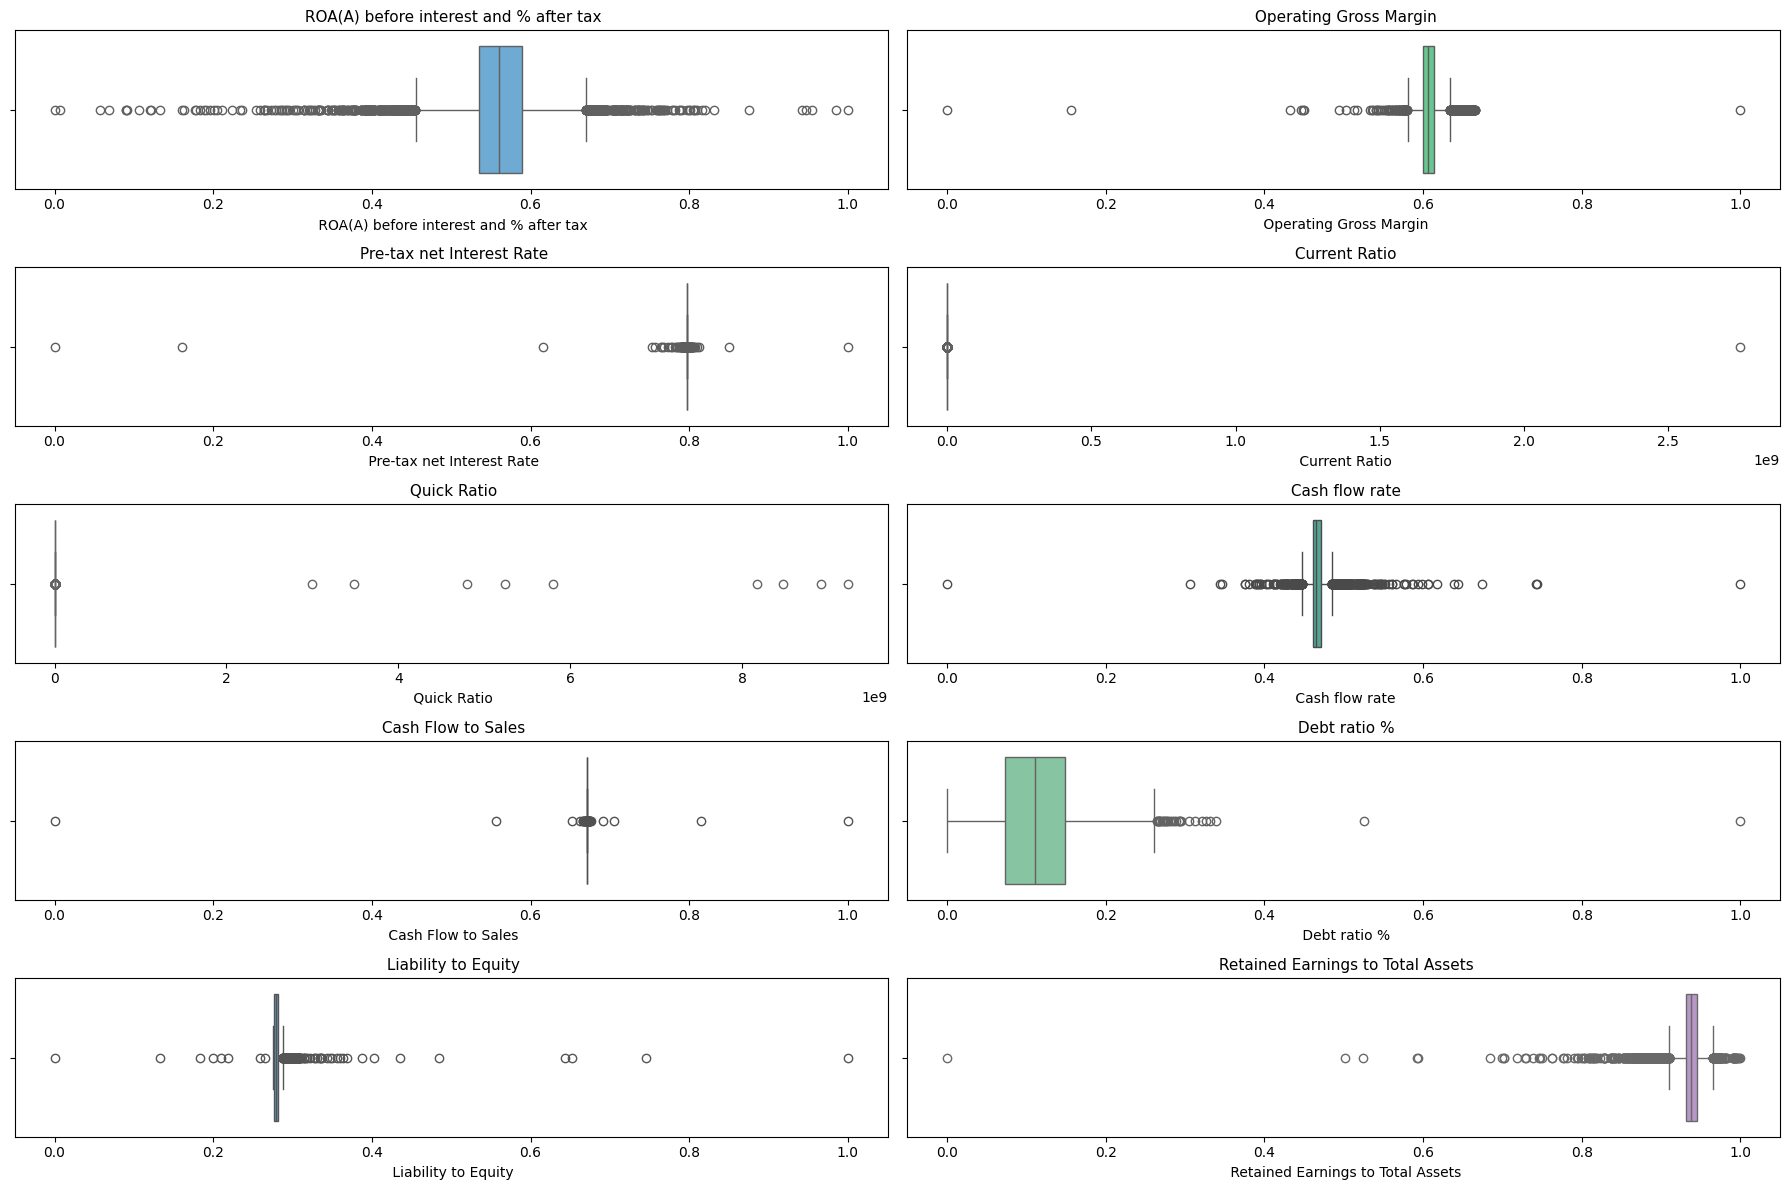

In [14]:
plt.figure(figsize=(18,12))

colors = [
    '#5DADE2',
    '#58D68D',
    '#F5B041',
    '#AF7AC5',
    '#EC7063',
    '#45B39D',
    '#DC7633',
    '#7DCEA0',
    '#5499C7',
    '#BB8FCE'
]

for i, col in enumerate(selected_features, 1):

    plt.subplot(5,2,i)

    sns.boxplot(
        x=df[col],
        color=colors[i-1]
    )

    plt.title(col, fontsize=11)

plt.tight_layout()

plt.show()

###Description

Boxplots were used to examine the presence of outliers and extreme values within the selected financial indicators. This analysis helps identify unusual financial observations that may affect statistical analysis and machine learning model performance.

###Observation

The boxplots reveal the presence of several outliers across multiple financial indicators.

ROA(A) before interest and % after tax:shows several extreme profitability values outside the normal range, indicating variation in company profitability performance.

Operating Gross Margin appears highly concentrated around similar values, although a limited number of companies contain unusually low or high operational margins.

Pre-tax net Interest Rate is concentrated near a narrow range, while a few extreme observations appear significantly different from the majority of companies.

Current Ratio contains extremely large outlier values, indicating strong variability in liquidity conditions between companies.

Quick Ratio also shows highly skewed behavior with several extreme liquidity observations compared to the overall dataset distribution.

Cash flow rate presents moderate outliers, suggesting differences in operational cash flow efficiency among companies.

Cash Flow to Sales is relatively concentrated, although a few companies contain unusual cash flow performance values.

Debt ratio % shows wider variability and several higher debt observations, reflecting differences in financial leverage and debt dependency across companies.

Liability to Equity contains a number of extreme leverage values, indicating that some companies rely heavily on debt financing.

Retained Earnings to Total Assets is concentrated near higher values, while a smaller number of companies appear significantly below the general distribution.

Overall, the results indicate that the dataset contains skewed financial behavior and several extreme observations, which is common in real-world financial datasets.

These outliers were not removed directly because they may represent financially distressed companies or unusual financial conditions that are important for bankruptcy prediction analysis.

Outlier detection is an important preprocessing step in financial data analysis because extreme observations may influence statistical modeling and machine learning performance (Han, Kamber, & Pei, 2012).

##Correlation Analysis and Feature Relationships

##Correlation Heatmap

This step analyzes the linear relationships between selected financial indicators and bankruptcy risk.

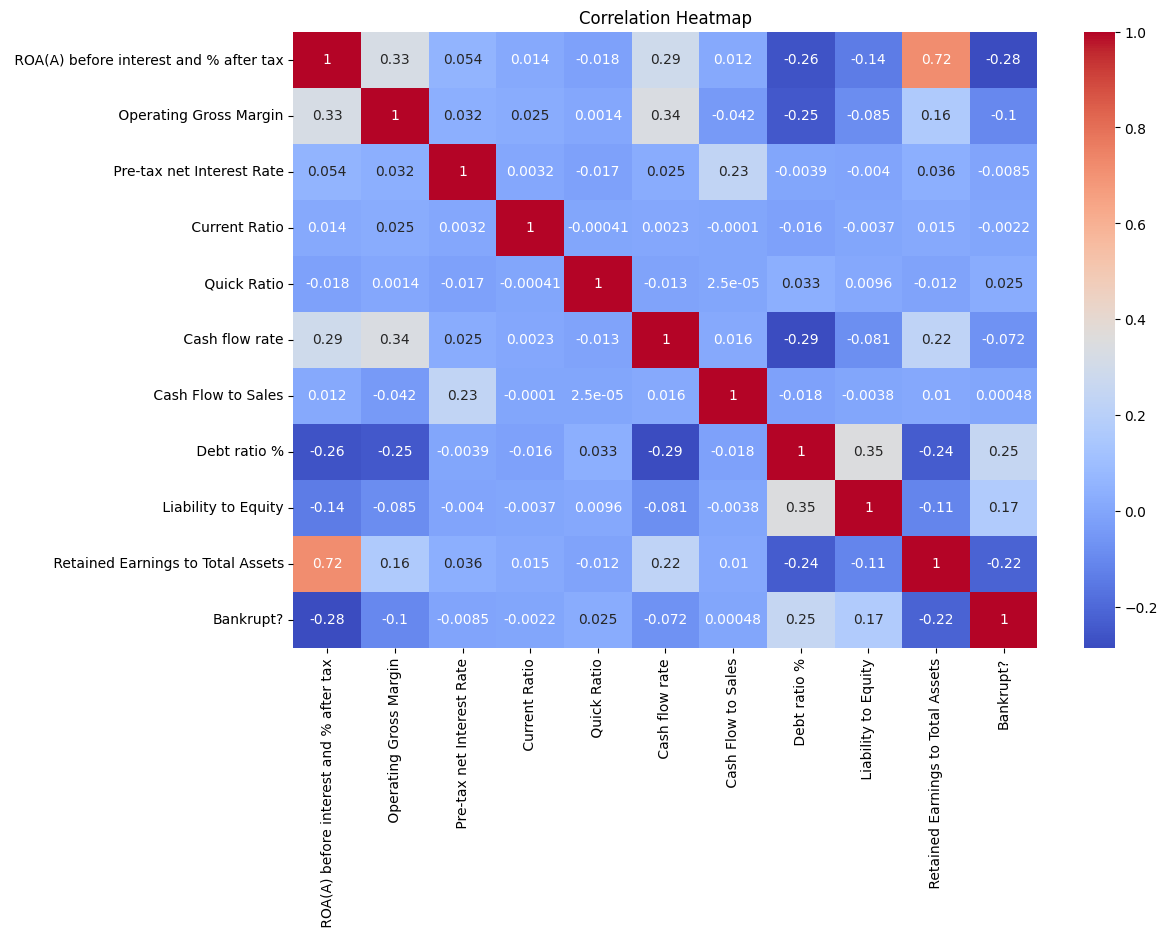

In [15]:
corr_features = selected_features + ['Bankrupt?']

plt.figure(figsize=(12,8))

sns.heatmap(df[corr_features].corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

##Correlation Ranking

The following step ranks financial indicators based on their correlation strength with bankruptcy risk.

In [16]:
correlations = df[selected_features + ['Bankrupt?']].corr()['Bankrupt?'].sort_values(ascending=False)

print(correlations)

Bankrupt?                                  1.000000
 Debt ratio %                              0.250161
 Liability to Equity                       0.166812
 Quick Ratio                               0.025058
 Cash Flow to Sales                        0.000479
 Current Ratio                            -0.002211
 Pre-tax net Interest Rate                -0.008517
 Cash flow rate                           -0.072356
 Operating Gross Margin                   -0.100043
 Retained Earnings to Total Assets        -0.217779
 ROA(A) before interest and % after tax   -0.282941
Name: Bankrupt?, dtype: float64


###Description

Correlation analysis was performed to examine the strength and direction of linear relationships between selected financial indicators and bankruptcy risk.

A correlation heatmap and correlation ranking were used to identify which financial variables are more strongly associated with the target variable (Bankrupt?).

###Key Findings

The correlation results indicate that most financial indicators have weak to moderate relationships with bankruptcy risk.

###Positive Relationships with Bankruptcy Risk

The following variables showed positive correlations with bankruptcy risk:

Debt ratio % (0.25)

Liability to Equity (0.17)

These results suggest that companies with higher debt dependence and financial leverage are generally more exposed to financial distress and bankruptcy risk.

###Negative Relationships with Bankruptcy Risk

The following variables showed negative correlations with bankruptcy risk:

ROA(A) before interest and % after tax (-0.28)

Retained Earnings to Total Assets (-0.22)

Operating Gross Margin (-0.10)

Cash flow rate (-0.07)

These findings indicate that companies with stronger profitability, operational performance, and retained earnings structures are less likely to experience bankruptcy.

###Weak Relationships

Several variables showed very weak correlations with bankruptcy risk, including:

Current Ratio (-0.002)

Quick Ratio (0.03)

Cash Flow to Sales (0.0005)

Pre-tax net Interest Rate (-0.009)

This indicates that these variables may have limited direct linear influence on bankruptcy prediction when analyzed individually.

###Business & Financial Insight

The analysis highlights that leverage-related indicators, particularly Debt Ratio % and Liability to Equity, are among the most influential financial factors associated with bankruptcy risk.

In contrast, profitability-related indicators such as ROA(A) and Retained Earnings to Total Assets appear to reduce the probability of financial failure and reflect stronger financial stability.

The generally weak to moderate correlations observed across several variables also suggest that bankruptcy prediction may involve complex and nonlinear financial relationships, supporting the use of advanced machine learning and deep learning techniques for more accurate bankruptcy prediction.

##Financial Comparison by Bankruptcy Status
Description

A comparative analysis was performed to examine differences in selected financial indicators between bankrupt and non-bankrupt companies.

Boxplots were used to visualize variations in financial ratios and identify whether certain indicators are associated with higher bankruptcy risk.

##Debt Ratio by Bankruptcy Status

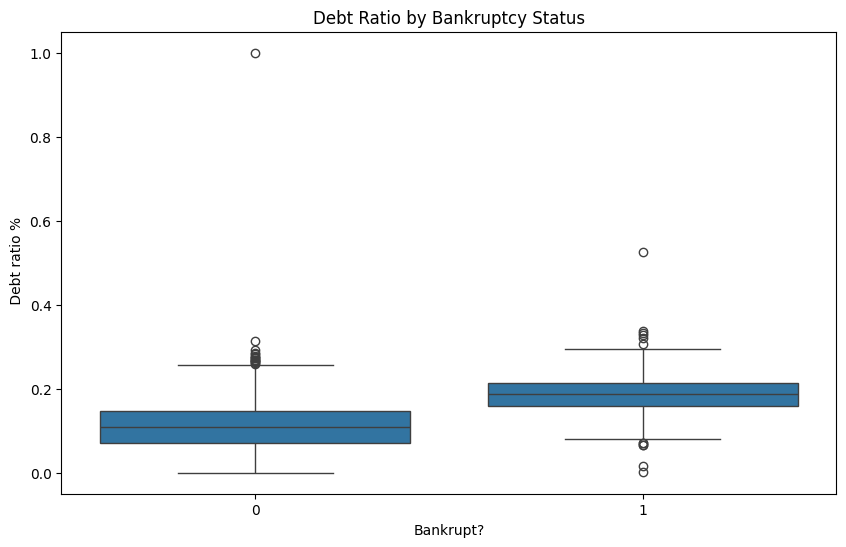

In [17]:
plt.figure(figsize=(10,6))

sns.boxplot(x='Bankrupt?', y=' Debt ratio %', data=df)

plt.title('Debt Ratio by Bankruptcy Status')

plt.show()

###Key Findings

The boxplot shows that bankrupt companies generally have higher debt ratio values compared to non-bankrupt companies.

The median debt ratio for bankrupt firms is noticeably higher, indicating greater dependence on debt financing and financial leverage. Several outliers are also observed in both groups, suggesting that some companies maintain unusually high debt levels.

###Business & Financial Insight

The results suggest that excessive debt dependence may increase financial distress and bankruptcy risk, making debt ratio an important indicator for financial risk evaluation.

##ROA(A) before interest and % after tax by Bankruptcy Status

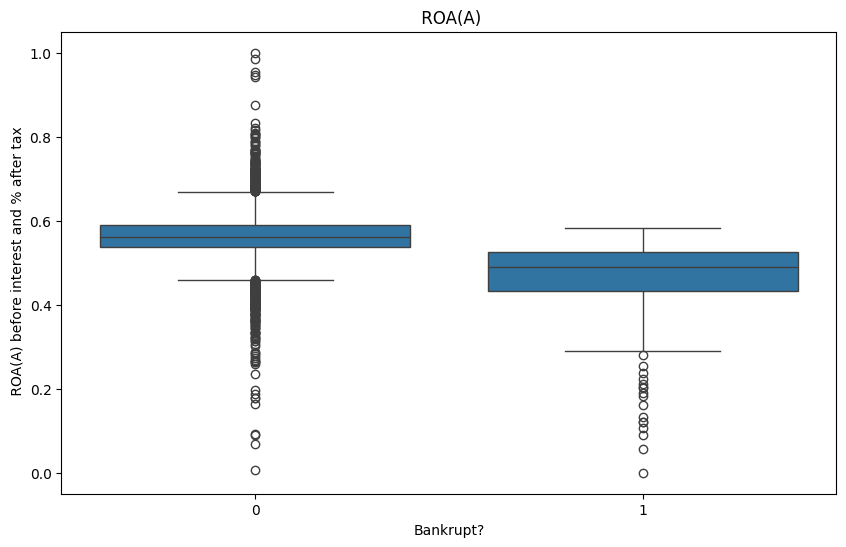

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(x='Bankrupt?', y= ' ROA(A) before interest and % after tax', data=df)

plt.title(' ROA(A)')

plt.show()

###Key Findings

The visualization indicates that non-bankrupt companies generally have higher profitability levels compared to bankrupt firms.

The median ROA(A) value for non-bankrupt companies is clearly higher, suggesting stronger operational performance and more efficient asset utilization. Bankrupt companies show lower profitability distributions and greater financial weakness.

Several outliers are also observed in both groups, reflecting variation in profitability performance across companies.

###Business & Financial Insight

The results indicate that stronger profitability performance may reduce bankruptcy risk, while lower ROA(A) values can be associated with financial instability and higher probability of financial failure.

##Financial Indicator Summary by Bankruptcy Status
This step summarizes selected financial indicators for bankrupt and non-bankrupt companies to support financial insight generation.

In [19]:
summary_table = df.pivot_table(
    values=[
        ' Operating Gross Margin',
        ' Quick Ratio',
        ' Cash flow rate',
        ' Retained Earnings to Total Assets',
        ' Liability to Equity'
    ],
    index='Bankrupt?',
    aggfunc=['mean', 'median']
)

summary_table.round(3)

mean                                             \
          Cash flow rate Liability to Equity Operating Gross Margin   
Bankrupt?                                                             
0                  0.468               0.280                  0.608   
1                  0.461               0.294                  0.599   

                                                                  median  \
            Quick Ratio Retained Earnings to Total Assets Cash flow rate   
Bankrupt?                                                                  
0          7.257160e+06                             0.936          0.465   
1          4.195455e+07                             0.904          0.461   

                                                                  \
          Liability to Equity Operating Gross Margin Quick Ratio   
Bankrupt?                                                          
0                       0.279                  0.606       0.008   
1                       0.286                  0.599       0.003   

                                             
          Retained Earnings to Total Assets  
Bankrupt?                                    
0                                     0.938  
1                                     0.913

###Key Findings
Bankrupt companies show higher Debt ratio % and Liability to Equity values.
Non-bankrupt companies demonstrate stronger:

ROA(A) before interest and % after tax

Cash flow rate

Retained Earnings to Total Assets

These results indicate that profitable companies with stronger retained earnings and lower financial leverage are generally more financially stable.

###Business & Financial Insight

The comparison highlights the importance of profitability, debt management, and retained earnings in assessing bankruptcy risk and overall financial stability.



##Bankruptcy Distribution Across Debt Categories

In [20]:
df[' Debt_Category'] = pd.qcut(
    df[' Debt ratio %'],
    q=3,
    labels=['Low Debt', 'Medium Debt', 'High Debt']
)

debt_pivot = pd.pivot_table(
    df,
    index=' Debt_Category',
    columns='Bankrupt?',
    values=' Debt ratio %',
    aggfunc='count',
    fill_value=0
)

debt_pivot

Bankrupt?,0,1
Debt_Category,,
Low Debt,2266,7
Medium Debt,2249,25
High Debt,2084,188


##Percentage distribution

In [21]:
debt_percentage = debt_pivot.div(debt_pivot.sum(axis=1), axis=0) * 100

debt_percentage.round(2)

Bankrupt?,0,1
Debt_Category,,
Low Debt,99.69,0.31
Medium Debt,98.90,1.10
High Debt,91.73,8.27


###Description

A pivot table analysis was performed to examine the distribution of bankruptcy cases across different debt ratio categories.

The Debt Ratio % variable was divided into three quantile-based groups (Low, Medium, and High Debt) using equal-frequency binning.

Both count-based and percentage-based pivot tables were generated to compare bankruptcy concentration across leverage categories.

###Key Findings

The results show a clear increase in bankruptcy concentration as debt levels rise.

Companies in the Low Debt category show only 0.31% bankruptcy cases.
The Medium Debt category contains approximately 1.10% bankrupt companies.
The High Debt category shows the highest bankruptcy proportion at 8.27%.

This demonstrates that firms with higher leverage levels are substantially more exposed to financial distress and bankruptcy risk.

###Business & Financial Insight

The analysis indicates that debt burden is a major financial risk factor associated with corporate bankruptcy.

As leverage increases, companies may experience higher repayment obligations, lower financial flexibility, and greater exposure to financial instability.

These findings support the importance of leverage monitoring in financial risk assessment and bankruptcy prediction systems.

#Statistical Testing

This section applies statistical testing methods to determine whether the differences between bankrupt and non-bankrupt companies are statistically significant.

The independent samples T-test was used to compare the mean values of both groups.

###Hypotheses

For each selected financial indicator:

H₀: There is no statistically significant difference between bankrupt and non-bankrupt companies.

H₁: There is a statistically significant difference between bankrupt and non-bankrupt companies.

##1- Test for ROA(A)


In [22]:
from scipy.stats import ttest_ind

bankrupt_roa = df[df['Bankrupt?'] == 1][' ROA(A) before interest and % after tax']

non_bankrupt_roa = df[df['Bankrupt?'] == 0][' ROA(A) before interest and % after tax']

t_stat, p_value = ttest_ind(bankrupt_roa, non_bankrupt_roa)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -24.356285199252728
P-Value: 1.0337410471215887e-125


##2 T-Test for Debt Ratio %

In [23]:
bankrupt_debt = df[df['Bankrupt?'] == 1][' Debt ratio %']

non_bankrupt_debt = df[df['Bankrupt?'] == 0][' Debt ratio %']

t_stat, p_value = ttest_ind(bankrupt_debt, non_bankrupt_debt)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 21.332865495971728
P-Value: 8.373954375308918e-98


##3 T-Test for Current Ratio

In [24]:
bankrupt_current = df[df['Bankrupt?'] == 1][' Current Ratio']

non_bankrupt_current = df[df['Bankrupt?'] == 0][' Current Ratio']

t_stat, p_value = ttest_ind(bankrupt_current, non_bankrupt_current)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -0.1825750780857307
P-Value: 0.8551368694703342


##4 T-Test for Cash Flow Rate

In [25]:
bankrupt_cashflow = df[df['Bankrupt?'] == 1][' Cash flow rate']

non_bankrupt_cashflow = df[df['Bankrupt?'] == 0][' Cash flow rate']

t_stat, p_value = ttest_ind(bankrupt_cashflow, non_bankrupt_cashflow)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -5.989744884785835
P-Value: 2.208652184347523e-09


###Result Interpretation
###Key Findings

The statistical testing results indicate that several financial indicators show statistically significant differences between bankrupt and non-bankrupt companies.

ROA(A) shows a statistically significant difference with a very small p-value (p < 0.05) and a negative T-statistic, indicating that bankrupt companies generally have lower profitability levels compared to non-bankrupt firms.

Debt Ratio % also demonstrates a statistically significant difference (p < 0.05) with a positive T-statistic, suggesting that bankrupt companies tend to have higher debt dependence and financial leverage.

Cash Flow Rate shows a statistically significant difference (p < 0.05), indicating that weaker cash flow performance may be associated with higher bankruptcy risk.

In contrast, Current Ratio does not show a statistically significant difference (p > 0.05), suggesting that liquidity measured by Current Ratio alone may not effectively distinguish bankrupt companies from financially stable firms in this dataset.

Overall, the statistical testing results support the findings obtained from the exploratory analysis, correlation analysis, and financial comparison sections.

###Business & Financial Insight

The analysis confirms that profitability, leverage, and cash flow performance are important financial indicators associated with bankruptcy risk.

The results also suggest that relying on a single liquidity indicator may not be sufficient for bankruptcy prediction. Instead, combining multiple financial indicators can provide a more reliable understanding of corporate financial distress.

These findings support the use of machine learning and deep learning models capable of capturing complex financial relationships for more accurate bankruptcy prediction.

#Dataset Challenges Identified During Analysis

Several challenges were identified during the exploratory analysis process.

### Observation

The following challenges were identified during the analysis:

- The dataset is highly imbalanced because bankrupt companies represent a small percentage of the data.
- Several financial indicators contain outliers and extreme values.
- Some financial relationships appear to be nonlinear and complex.
- The dataset contains many financial variables, which increases model complexity.

These challenges will be addressed during preprocessing and model development stages.

#Data Visualization and Insights

##Dashboard Design & Business Insights

Interactive Power BI dashboards were developed to visualize financial risk patterns, support business decision-making, and improve bankruptcy risk interpretation.

Several additional analytical columns and business indicators were also created inside Power BI based on the results of exploratory analysis, clustering, and predictive modeling outputs.

These dashboards were designed to support Decision Support System (DSS) objectives by transforming complex financial data into clear business insights and actionable risk indicators.

##Dashboard 1 — Executive Financial Risk Overview

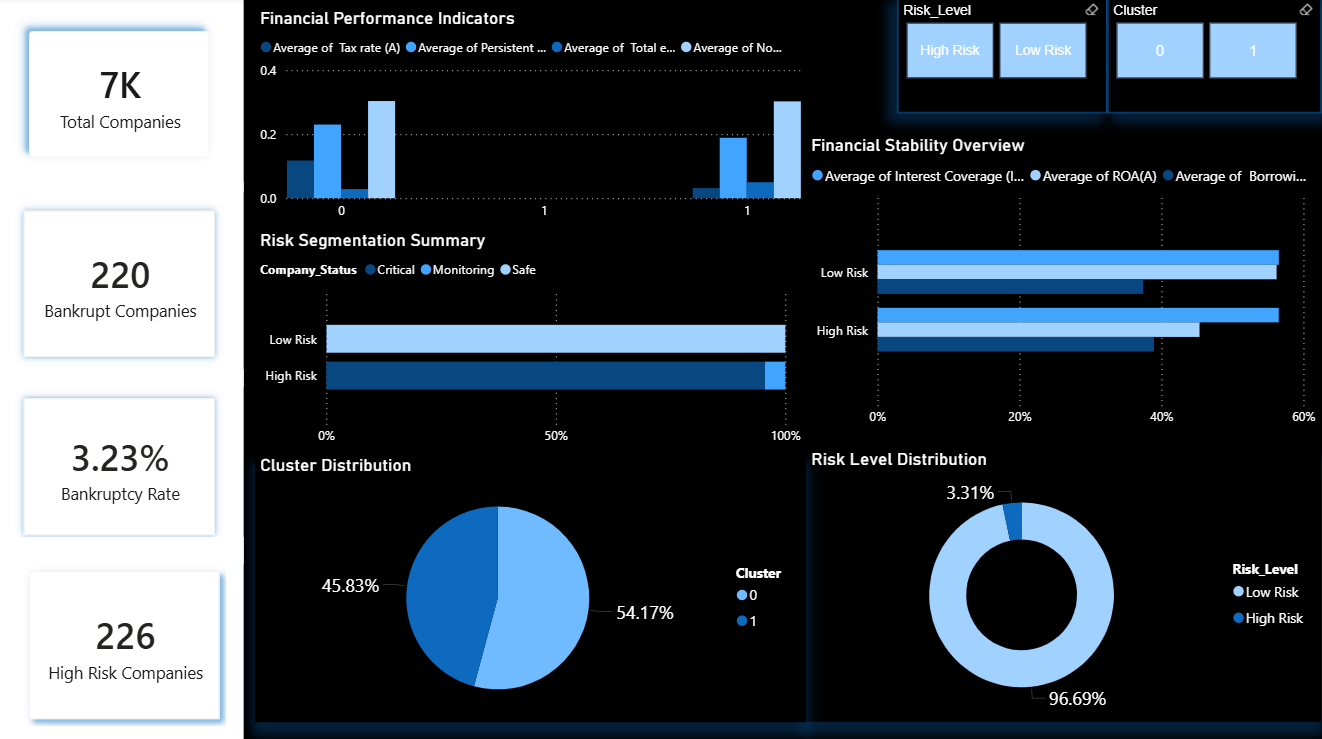

##Dashboard Purpose

This dashboard provides a high-level overview of bankruptcy risk, company classification, and financial stability indicators. It combines machine learning predictions, clustering analysis, and financial KPIs to support financial monitoring and decision-making.

##Key Components
##1. Bankruptcy Probability by Risk Level

This chart compares the average predicted bankruptcy probability between High-Risk and Low-Risk companies.

###Business Use:
Helps decision-makers identify how strongly the AI model separates risky companies from financially stable companies.

##2. Actual Bankruptcy Distribution

This bar chart displays the number of bankrupt and non-bankrupt companies in the dataset.

###Business Use:
Provides a quick overview of the bankruptcy distribution and highlights the imbalance between healthy and bankrupt firms.

##3. Cluster Distribution

This pie chart shows the distribution of companies across clustering groups generated using K-Means clustering.

###Business Use:
Supports segmentation analysis and helps identify financially risky and financially stable company groups.

##4. Borrowing Dependency by Bankruptcy Status

This chart compares borrowing dependency between bankrupt and non-bankrupt companies.

###Business Use:
Shows that financially distressed companies generally rely more heavily on debt financing.

##5. Risk Level Distribution

This donut chart presents the proportion of High-Risk and Low-Risk companies identified by the prediction model.

###Business Use:
Helps management understand the overall financial risk exposure across companies.

##6. KPI Cards

The KPI cards summarize the most important financial monitoring indicators:

Total Companies

Bankrupt Companies

Bankruptcy Rate

Average Bankruptcy Probability

High-Risk Companies

###Business Use:
Provides an executive-level summary for rapid financial monitoring and bankruptcy risk assessment.

##7. Filters and Slicers

The dashboard includes interactive slicers for:

Risk Level

Cluster

###Business Use:
Allows users to dynamically explore financial behavior across different company groups and risk categories.

##Dashboard 2 — Financial Relationship & Risk Analysis

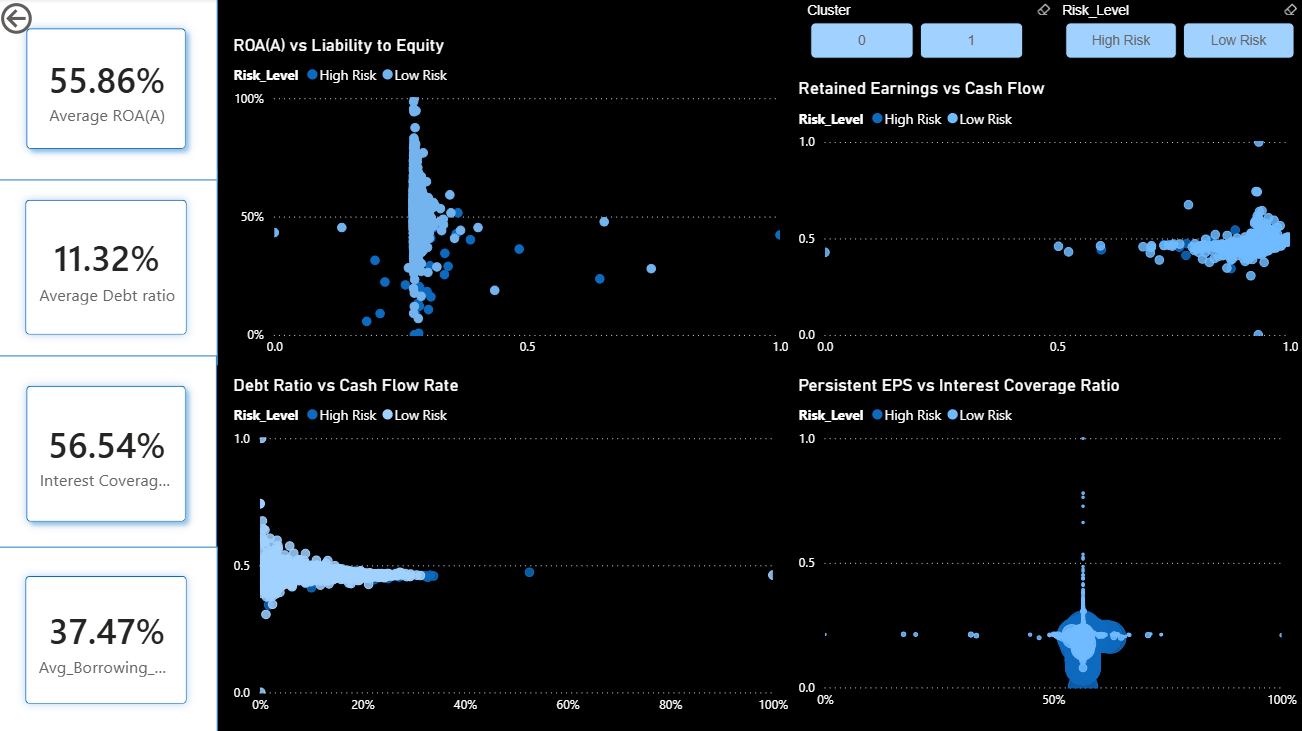

##Dashboard Purpose

This dashboard focuses on analyzing financial relationships between profitability, leverage, liquidity, retained earnings, and bankruptcy risk. It helps identify financial behavior patterns associated with high-risk companies.

##Key Components
##1. ROA(A) vs Liability to Equity

This scatter plot analyzes the relationship between profitability and financial leverage across risk categories.

###Business Use:
Helps identify how high leverage and lower profitability are associated with increased bankruptcy risk.

##2. Retained Earnings vs Cash Flow

This chart compares retained earnings and financial cash flow behavior between High-Risk and Low-Risk companies.

###Business Use:
Supports evaluation of long-term financial sustainability and internal financing strength.

##3. Debt Ratio vs Cash Flow Rate

This scatter plot explores the relationship between debt exposure and cash flow performance.

###Business Use:
Shows how increasing debt levels may negatively affect financial liquidity and operational cash flow stability.

##4. Persistent EPS vs Interest Coverage Ratio

This visualization examines the relationship between earnings stability and the company’s ability to cover interest expenses.

###Business Use:
Helps assess financial resilience and the ability of firms to sustain profitability under debt obligations.

##5. KPI Cards

The KPI cards summarize key financial indicators:

Average ROA(A)

Average Debt Ratio

Interest Coverage Ratio

Average Borrowing Dependency

###Business Use:
Provides a quick overview of profitability, leverage, liquidity, and borrowing behavior for financial monitoring.

##6. Filters and Slicers

The dashboard includes interactive slicers for:

Cluster

Risk Level

###Business Use:
Allows dynamic exploration of financial relationships across different company segments and risk categories.

##Dashboard 3 — Decision Support & Risk Monitoring

![image.png]()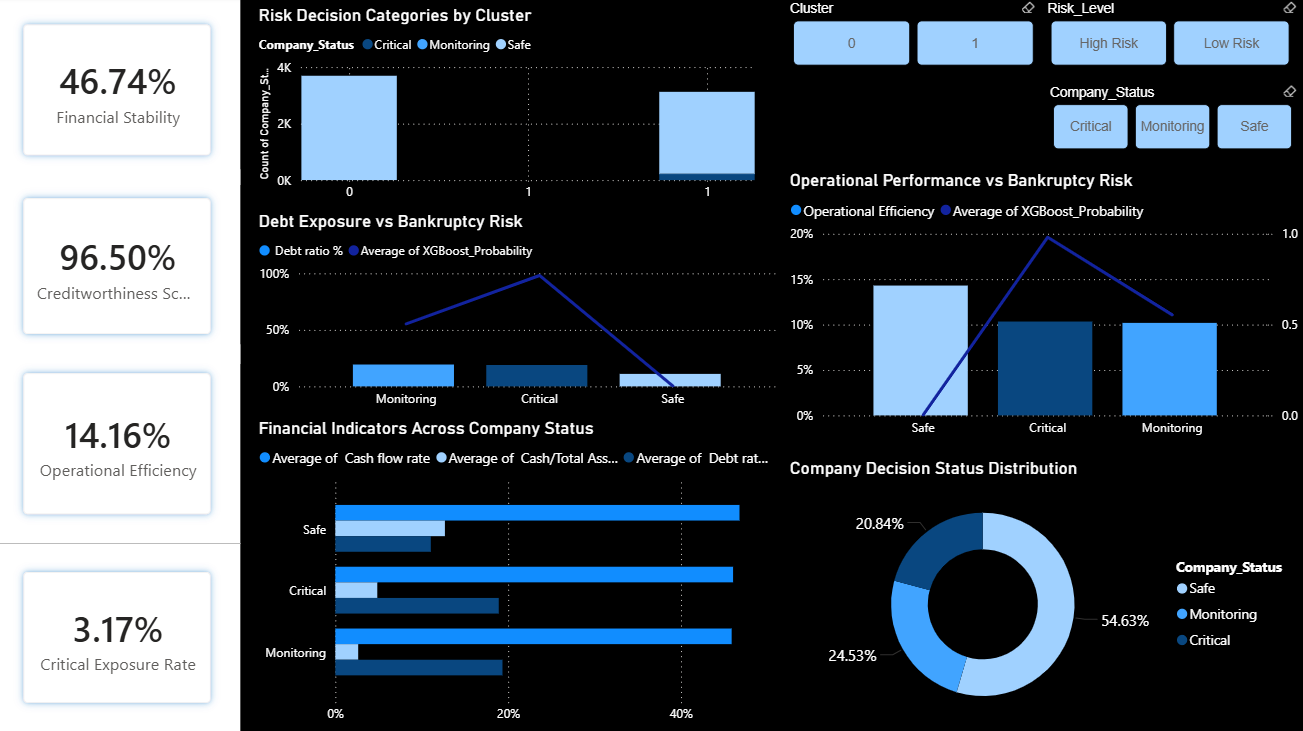

##Dashboard Purpose

This dashboard was designed as an executive Decision Support System (DSS) for bankruptcy monitoring, financial risk evaluation, and company classification. It combines predictive analytics, clustering analysis, and financial performance indicators to support data-driven financial decisions.

##Key Components
##1. Risk Decision Categories by Cluster

This chart displays the distribution of Safe, Monitoring, and Critical companies across clustering groups.

###Business Use:
Helps decision-makers identify how financial risk categories are distributed within different company clusters.

##2. Debt Exposure vs Bankruptcy Risk

This combo chart compares debt ratio levels with average bankruptcy probability across company statuses.

###Business Use:
Shows how increasing debt exposure is associated with higher bankruptcy risk, especially for Critical companies.

##3. Operational Performance vs Bankruptcy Risk

This visualization compares operational efficiency with predictive bankruptcy probability.

###Business Use:
Helps evaluate how operational performance influences financial risk and company stability.

##4. Financial Indicators Across Company Status

This chart compares multiple financial indicators, including:

Cash Flow Rate

Cash/Total Assets

Debt Ratio %

across Safe, Monitoring, and Critical companies.

###Business Use:
Supports financial profiling and highlights the financial differences between company categories.

##5. Company Decision Status Distribution

This donut chart presents the proportion of Safe, Monitoring, and Critical companies.

###Business Use:
Provides a clear executive overview of company financial classification and overall financial health distribution.

##6. KPI Cards

The KPI cards summarize important financial monitoring indicators:

Financial Stability

Creditworthiness Score

Operational Efficiency

Critical Exposure Rate

###Business Use:
Provides quick executive-level monitoring of financial condition, company stability, and bankruptcy exposure.

##7. Filters and Slicers

The dashboard includes interactive slicers for:

Cluster

Risk Level

Company Status

###Business Use:
Allows dynamic filtering and interactive exploration of financial behavior across different company groups and risk categories.

#Data Preprocessing

This section prepares the dataset for machine learning and deep learning models by removing highly correlated features, scaling the data, handling class imbalance, and splitting the dataset into training  and testing sets.

##Remove temporary categorical analysis column

In [26]:
df = df.drop(columns=[' Debt_Category'])

###Description

A temporary categorical column (Debt_Category) created for exploratory pivot table analysis was removed before preprocessing and model development.

Key Findings

The column was excluded because it was generated only for analytical segmentation purposes and could introduce redundancy or data leakage during machine learning training.

Business & Modeling Insight

Removing temporary analytical variables helps maintain a clean modeling dataset and prevents artificial relationships from influencing bankruptcy prediction models.

##Correlation-Based Feature Reduction

In [27]:
X = df.drop(columns=['Bankrupt?'])

y = df['Bankrupt?']

In [28]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column for column in upper.columns
    if any(upper[column] > 0.95)
]

In [29]:
X = X.drop(columns=high_corr_features)

print(X.shape)

(6819, 79)


###Description

Highly correlated financial variables were identified and removed using a correlation threshold of 0.95 to reduce redundancy and minimize multicollinearity effects.

###Key Findings

Several highly repetitive financial indicators were removed, including:

ROA(B) before interest and depreciation after tax
Realized Sales Gross Margin
After-tax net Interest Rate

After feature reduction, the number of variables decreased from 95 to 79 features.

###Business & Modeling Insight

Feature reduction simplified the dataset while preserving important financial indicators related to bankruptcy prediction.

##Train-Test Split


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

###Description

The dataset was divided into training and testing subsets using stratified sampling to preserve the original bankruptcy class distribution.

###Key Findings

A test size of 20% was used, while 80% of the data was allocated for model training.

Stratified sampling ensured that both bankrupt and non-bankrupt classes remained proportionally distributed across the training and testing datasets.

###Business & Modeling Insight

Maintaining class distribution during data splitting improves evaluation reliability and helps ensure that model performance reflects real financial bankruptcy patterns.

##Feature Scaling



In [31]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

pd.DataFrame(X_train_scaled).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78
0,-0.176677,-0.117303,-0.542117,0.014704,0.016414,-0.007591,1.489010,-0.748887,-0.065632,-0.151822,0.578043,0.348356,-0.216287,-0.132579,-0.022115,-0.388536,-0.003226,0.032023,0.095186,0.312533,0.585176,-0.013541,0.080524,0.052407,-0.160709,-0.034023,-0.020414,-0.023638,-1.083483,-0.122980,-0.351417,-0.016414,-0.368932,0.010330,-0.044273,-0.039286,-0.661815,-0.409146,-0.300304,-0.013541,-0.229818,-0.038392,-0.434131,-1.253999,-1.055283,-0.830000,-0.02341,-0.072261,-0.828195,-0.030308,0.003326,-0.097433,0.248580,-0.161034,-0.281271,-0.097228,-0.060811,-0.014809,-0.617879,2.293713,0.471418,-0.025701,-0.634029,-0.018780,-0.013541,-0.252473,-0.300176,-0.199694,-0.117743,-0.137548,-0.190312,-0.030289,-0.04968,-0.013322,0.019121,-0.047674,-0.002594,0.0,0.475372
1,0.496220,0.504173,-0.496455,0.017875,0.017367,-0.013713,0.478365,-0.748887,-0.131227,-0.151822,0.998953,0.189136,0.649462,0.398657,-0.022115,0.956161,-0.017128,0.029029,0.034927,-0.003543,-1.656456,-0.013541,0.054834,0.188031,-0.160037,-0.034023,-0.006233,-0.023638,0.870610,-0.103389,0.039364,0.114630,0.952755,2.500991,-0.044273,-0.039286,-0.661815,-0.409146,1.657220,-0.013541,0.777465,-0.038392,0.652619,1.700036,1.267121,-0.636123,-0.02341,-0.072261,0.821530,-0.116354,-0.035959,-0.097433,0.111845,0.429017,0.175030,-0.097228,0.292229,-0.003339,-0.415672,-0.155201,1.578574,-0.025745,-0.500196,-0.017541,-0.013541,0.063315,-0.013055,-0.054251,0.313115,0.019307,-0.191546,-0.030289,-0.04968,0.039302,0.259424,-0.045491,0.009096,0.0,-0.509747
2,0.363741,0.444945,-0.060126,0.023791,0.030626,-0.005259,1.752522,-0.205997,0.195128,-0.151822,0.861056,-0.068585,0.074272,0.000230,-0.022115,0.076261,-0.053701,0.015835,0.025690,-0.005329,0.360148,-0.013541,-0.009807,-0.242242,0.103272,-0.034023,-0.028360,-0.023638,-0.899556,-0.112657,-0.351417,-0.046865,-0.343071,-0.185904,-0.044273,-0.039286,-0.661815,-0.409146,-0.339025,-0.013541,0.020564,-0.038392,0.362928,0.311491,-0.224250,0.807019,-0.02341,-0.072261,-0.775262,0.207822,-0.042188,-0.097433,-0.143224,0.048712,-0.269261,-0.097228,0.285853,0.010955,-0.656487,-0.423759,-0.644596,-0.017955,-0.845789,-0.013073,-0.013541,-0.252473,0.563513,0.343774,0.238679,0.224626,-0.497354,-0.030289,-0.04968,0.072530,0.142392,-0.048977,-0.009972,0.0,0.253378
3,-0.575729,-0.320846,-0.726880,0.013707,0.011745,-0.013214,0.341959,-0.748887,-0.238211,-0.151822,1.615517,-0.223757,-0.373427,0.151715,-0.022115,-0.423615,-0.089300,0.009975,0.022757,-0.004839,0.207820,-0.013541,-0.037570,0.539985,-0.243286,-0.034023,0.169444,-0.023638,1.059554,-0.030343,-0.124340,-0.046865,0.547901,0.478272,-0.044273,-0.039286,-0.661815,-0.409146,0.512821,-0.013541,-0.223343,-0.038392,0.415432,1.944110,1.709395,-0.227311,-0.02341,-0.072261,1.720439,-0.195463,-0.027310,-0.097433,1.133358,0.378050,0.435409,-0.097228,0.024344,-0.023141,-0.733778,-0.423759,-0.644596,-0.022370,0.916054,-0.014973,-0.013541,-0.252473,0.526162,0.073242,0.116678,0.444912,-0.014590,-0.030289,-0.04968,0.064900,-0.018003,0.001739,0.149999,0.0,-0.541738
4,-1.870631,-1.753995,3.328187,-0.215758,-0.275531,0.051511,-0.612884,-0.748887,-1.927154,-0.151822,-0.820418,-0.893022,-0.806301,-0.601561,-0.022115,-0.865027,-0.066479,-0.075669,-0.155520,-0.032938,-1.907449,-0.013541,-0.385845,-0.618073,2.143359,-0.034023,-0.028452,-0.023638,-1.826998,0.262336,-0.351417,-0.046865,-0.670549,-1.318023,-0.044273,-0.039286,-0.655927,-0.409146,-0.764947,-0.013541,-0.583806,-0.038392,1.612669,1.309178,0.528298,-0.636057,-0.02341,-0.072261,-1.422408,-2.602451,-0.046410,-0.097433,1.146819,0.246063,-0.361786,-0.097228,-0.670633,-0.039172,0.281908,-0.423759,-0.644596,0.348081,-0.845789,-0.063010,-0.013541,-0.252473,-0.569783,-1.054182,-1.228358,-0.222198,-0.920690,-0.030289,-0.04968,0.034003,-0.215186,-0.048990,-

###Description

Financial indicators were standardized using StandardScaler to normalize feature ranges before machine learning and deep learning training.

###Key Findings

The transformed dataset shows standardized numerical values centered around zero with reduced scale variability between financial indicators.

###Business & Modeling Insight

Feature scaling improves model stability and learning efficiency, particularly for algorithms sensitive to feature magnitude such as neural networks, logistic regression, and distance-based models.

##Handling Imbalanced Data

In [32]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

##Class Distribution Comparison Before & After Imbalance Handling

In [33]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_balanced.value_counts())

Before SMOTE:
Bankrupt?
0    5279
1     176
Name: count, dtype: int64

After SMOTE:
Bankrupt?
0    5279
1    5279
Name: count, dtype: int64


###Description

SMOTE (Synthetic Minority Over-sampling Technique) was applied to address class imbalance within the bankruptcy dataset.

###Key Findings

Before applying SMOTE:

	•Non-bankrupt companies: 5279

	•Bankrupt companies: 176


After applying SMOTE:

	•Non-bankrupt companies: 5279

	•Bankrupt companies: 5279

The minority bankruptcy class was successfully balanced using synthetic sample generation.

###Business & Modeling Insight

Balancing the dataset improves the ability of machine learning models to detect financially distressed companies and reduces bias toward the majority non-bankrupt class.

##Final Dataset Shapes

In [34]:
print("X_train_balanced:", X_train_balanced.shape)
print("y_train_balanced:", y_train_balanced.shape)
print("X_test:", X_test_scaled.shape)
print("y_test:", y_test.shape)

X_train_balanced: (10558, 79)
y_train_balanced: (10558,)
X_test: (1364, 79)
y_test: (1364,)


###Description

The final dataset dimensions were verified after preprocessing, feature reduction, scaling, and imbalance handling.

###Key Findings

	•	X_train_balanced: (10558, 79)

	•	y_train_balanced: (10558,)

	•	X_test: (1364, 79)

	•	y_test: (1364,)

###Business & Modeling Insight

The dataset is now fully prepared for machine learning and deep learning model development with balanced classes, standardized features, and reduced redundancy.

##Download The Processed Data File



In [66]:
processed_data = X.copy()

processed_data["Bankrupt?"] = y

processed_data.to_csv("processed_data.csv", index=False)

In [67]:
from google.colab import files
files.download("processed_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Advanced Analytics and AI Modeling

##Modeling Methodology

Different machine learning and deep learning models were selected to analyze bankruptcy risk from multiple perspectives.

The selected models were chosen based on the characteristics of the financial dataset, including nonlinear relationships, outliers, class imbalance, and the large number of financial indicators.

Financial ratios and machine learning techniques are widely used in bankruptcy prediction research because they help identify financial distress patterns and support decision-making processes (Altman, 1968).

##Supervised Models

##1 XGBoost Classifier

XGBoost was selected because it performs efficiently on structured financial datasets and can capture complex nonlinear relationships between financial indicators and bankruptcy risk.

The model is also robust to outliers and performs well in classification problems involving imbalanced datasets.

XGBoost has been widely used in financial prediction and classification tasks due to its strong predictive performance and scalability (Chen & Guestrin, 2016).

##2 MLP Neural Network

The MLP Neural Network was selected to evaluate deep learning performance on financial data.

This model can learn complex interactions between financial variables and identify hidden nonlinear patterns that may not be captured by traditional statistical methods.

Neural Networks are commonly used in financial analytics because of their ability to model complex relationships in high-dimensional datasets (Haykin, 2009).

##Unsupervised Model

##3 K-Means Clustering

K-Means clustering was used to group companies into financial risk categories based on similarities in financial indicators.

This unsupervised learning technique helps identify hidden financial patterns and classify companies into clusters such as financially stable firms, medium-risk firms, and high-risk firms.

Clustering techniques are widely used in business intelligence and decision support systems to support financial analysis and strategic decision-making.

## Model Evaluation Metrics

Several evaluation metrics were used to measure model performance and prediction quality.

### Classification Evaluation Metrics

The following evaluation metrics were used for XGBoost and MLP Neural Network models:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC Score
- Confusion Matrix

These metrics provide a comprehensive evaluation of bankruptcy prediction performance and classification effectiveness.

### Clustering Evaluation Metrics

Several methods were used to evaluate K-Means clustering performance, including:

- Elbow Method
- Silhouette Score
- Inertia
- Centroid Analysis
- Cluster Visualization

These methods help evaluate cluster quality and interpret financial risk patterns among companies.

#XGBoost Classifier

##Import Libraries

In [35]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

##Model Training


In [36]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_balanced, y_train_balanced)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

##Prediction Results



In [37]:
y_pred_xgb = xgb_model.predict(X_test_scaled)

y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:,1]

##Sample Prediction Results

In [38]:
prediction_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_xgb
})

prediction_results.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


##Model Evaluation

In [39]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

xgb_precision = precision_score(y_test, y_pred_xgb)

xgb_recall = recall_score(y_test, y_pred_xgb)

xgb_f1 = f1_score(y_test, y_pred_xgb)

xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1320
           1       0.50      0.57      0.53        44

    accuracy                           0.97      1364
   macro avg       0.74      0.77      0.76      1364
weighted avg       0.97      0.97      0.97      1364



##Confusion Matrix

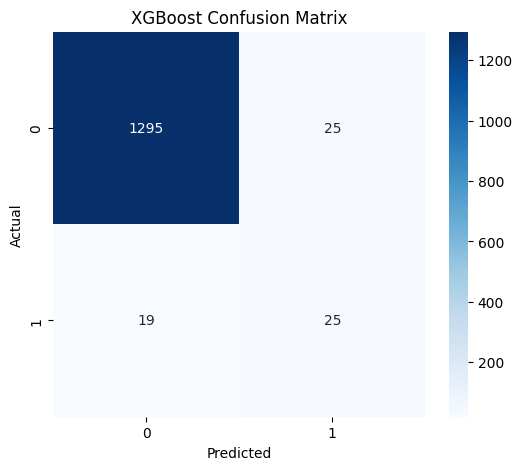

In [40]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("XGBoost Confusion Matrix")

plt.show()

##ROC Curve & AUC Score

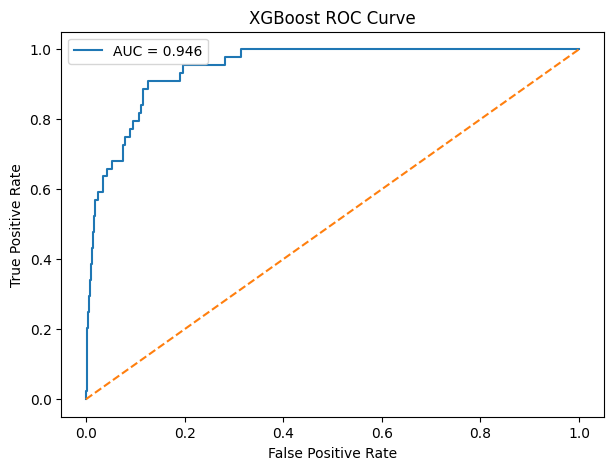

In [41]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {xgb_auc:.3f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("XGBoost ROC Curve")

plt.legend()

plt.show()

##Financial Feature Importance Analysis Using XGBoost

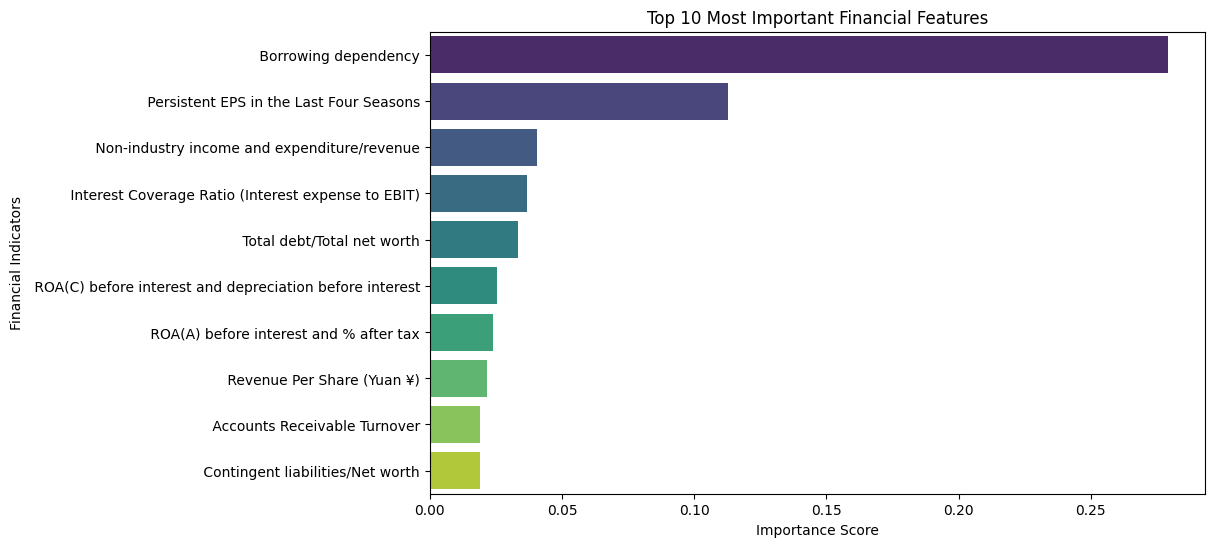

,Feature,Importance
30,Borrowing dependency,0.279197
12,Persistent EPS in the Last Four Seasons,0.112893
5,Non-industry income and expenditure/revenue,0.040735
76,Interest Coverage Ratio (Interest expense to ...,0.036671
27,Total debt/Total net worth,0.033561
0,ROA(C) before interest and depreciation befor...,0.025479
1,ROA(A) before interest and % after tax,0.023870
14,Revenue Per Share (Yuan ¥),0.021824
34,Accounts Receivable Turnover,0.019160
31,Contingent liabilities/Net worth,0.019108


In [42]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features,
    palette='viridis'
)

plt.title('Top 10 Most Important Financial Features')
plt.xlabel('Importance Score')
plt.ylabel('Financial Indicators')

plt.show()

top_features

##XGBoost Model Analysis

The XGBoost model was trained using the balanced financial dataset to predict bankruptcy risk based on multiple financial indicators.

###Model Performance

The model achieved strong classification performance:

Accuracy: 97%

ROC-AUC Score: 0.946

Precision: 0.50

Recall: 0.57

F1-Score: 0.53

These results indicate that the model was highly effective in distinguishing between bankrupt and non-bankrupt companies despite class imbalance challenges.

###Confusion Matrix Analysis

The confusion matrix results showed:

True Negatives: 1295

False Positives: 25

False Negatives: 19

True Positives: 25

The model demonstrated strong capability in identifying financially stable companies while maintaining moderate bankruptcy detection performance.

###Feature Importance Analysis

The most influential financial indicator was Borrowing Dependency with an importance score of approximately 0.279.

Other important indicators included:

Persistent EPS in the Last Four Seasons

Interest Coverage Ratio

Total Debt to Total Net Worth

ROA(A)

ROA(C)

These findings suggest that debt dependency, profitability, and earnings stability are major factors associated with bankruptcy risk.

###Overall Interpretation

Overall, the XGBoost model demonstrated excellent bankruptcy prediction capability and successfully captured complex financial relationships within the dataset.

The model can support financial institutions and decision-makers through early bankruptcy risk detection and financial risk assessment.

#MLP Neural Network Model

##Import Libraries

In [43]:
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

##Model Training

In [44]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,50),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp_model.fit(X_train_balanced, y_train_balanced)

MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)

##Prediction Results


In [45]:
y_pred_mlp = mlp_model.predict(X_test_scaled)

y_prob_mlp = mlp_model.predict_proba(X_test_scaled)[:,1]

##Sample Prediction Results

In [46]:
mlp_predictions = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_mlp
})

mlp_predictions.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,1
6,0,0
7,0,0
8,0,0
9,0,0


## Model Evaluation

In [47]:
mlp_accuracy = accuracy_score(y_test, y_pred_mlp)

mlp_precision = precision_score(y_test, y_pred_mlp)

mlp_recall = recall_score(y_test, y_pred_mlp)

mlp_f1 = f1_score(y_test, y_pred_mlp)

mlp_auc = roc_auc_score(y_test, y_prob_mlp)

print(classification_report(y_test, y_pred_mlp))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1320
           1       0.41      0.41      0.41        44

    accuracy                           0.96      1364
   macro avg       0.69      0.69      0.69      1364
weighted avg       0.96      0.96      0.96      1364



##Confusion Matrix

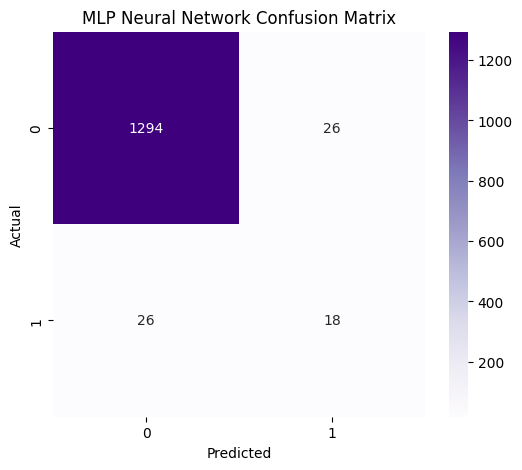

In [48]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("MLP Neural Network Confusion Matrix")

plt.show()

##ROC Curve & AUC Score

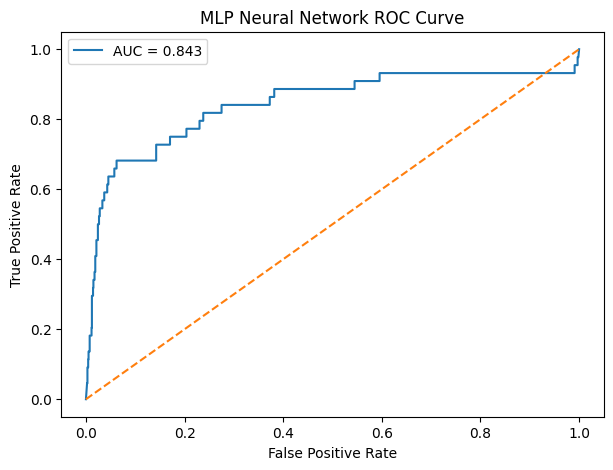

In [49]:
fpr_mlp, tpr_mlp, thresholds_mlp = roc_curve(
    y_test,
    y_prob_mlp
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr_mlp,
    tpr_mlp,
    label=f"AUC = {mlp_auc:.3f}"
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("MLP Neural Network ROC Curve")

plt.legend()

plt.show()

##MLP Neural Network Model Analysis

The MLP Neural Network model was trained using the balanced financial dataset to predict bankruptcy risk. The model used two hidden layers with 100 and 50 neurons, ReLU activation, Adam optimizer, and a maximum of 500 iterations.

Model Performance

The MLP model achieved good overall classification performance:

Accuracy: 96%

ROC-AUC Score: approximately 0.843

Precision for bankrupt class: 0.41

Recall for bankrupt class: 0.41

F1-Score for bankrupt class: 0.41

These results indicate that the model performed strongly in identifying non-bankrupt companies while showing moderate performance in detecting bankrupt companies.

###Confusion Matrix Analysis

The confusion matrix results showed:

True Negatives: 1294

False Positives: 26

False Negatives: 26

True Positives: 18

This means the model correctly classified most non-bankrupt companies, while some bankrupt companies were still difficult to identify accurately.

###ROC Curve Analysis

The ROC curve demonstrated good classification capability with an AUC score of approximately 0.843. This indicates that the MLP model was able to distinguish reasonably well between bankrupt and non-bankrupt companies.

###Overall Interpretation

Overall, the MLP Neural Network demonstrated effective learning of complex financial relationships and produced strong prediction performance on the bankruptcy dataset. The model successfully captured nonlinear financial patterns and provided reliable classification results for bankruptcy prediction tasks.

#Model Comparison and Evaluation

This section compares the performance of the machine learning and deep learning models used for bankruptcy prediction.

The evaluation focuses on classification accuracy, precision, recall, F1-score, and ROC-AUC performance to determine the most effective model for financial risk prediction.

##Create Comparison Table

In [50]:
comparison_table = pd.DataFrame({

    'Model': [
        'XGBoost',
        'MLP Neural Network'
    ],

    'Accuracy': [
        xgb_accuracy,
        mlp_accuracy
    ],

    'Precision': [
        xgb_precision,
        mlp_precision
    ],

    'Recall': [
        xgb_recall,
        mlp_recall
    ],

    'F1-Score': [
        xgb_f1,
        mlp_f1
    ],

    'ROC-AUC': [
        xgb_auc,
        mlp_auc
    ]
})

comparison_table.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.968,0.500,0.568,0.532,0.946
1,MLP Neural Network,0.962,0.409,0.409,0.409,0.843


###Comparison Analysis

The comparison results show that both models achieved high classification accuracy above 96%.

However, the XGBoost model achieved better overall performance across Recall, F1-Score, and ROC-AUC metrics, indicating stronger capability in detecting bankrupt companies and handling imbalanced financial data.

The MLP Neural Network model achieved reasonable performance but showed lower effectiveness in identifying financially risky companies.

## Model Performance Visualization

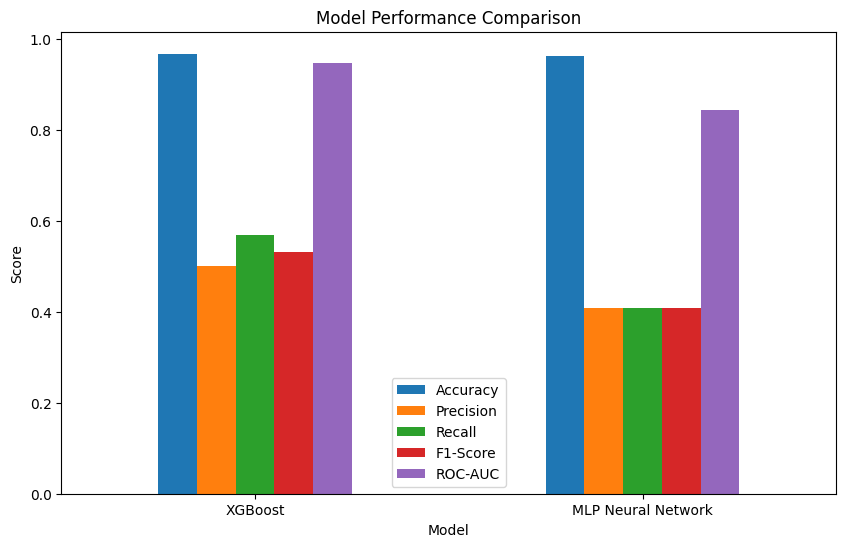

In [51]:
comparison_plot = comparison_table.set_index('Model')

comparison_plot.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

##Final Model Selection

Based on the evaluation results, the XGBoost model was selected as the final bankruptcy prediction model.

The model achieved the strongest overall performance, particularly in Recall and ROC-AUC metrics, making it more suitable for financial risk prediction and bankruptcy detection.

#K-Means Clustering Model

##Feature Selection for Clustering


In [52]:
clustering_features = [
    ' ROA(A) before interest and % after tax',
    ' Debt ratio %',
    ' Cash flow rate',
    ' Retained Earnings to Total Assets',
    ' Liability to Equity'
]

X_cluster = df[clustering_features]

##Feature Scaling

In [53]:
from sklearn.preprocessing import StandardScaler

scaler_cluster = StandardScaler()

X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

##Elbow Method

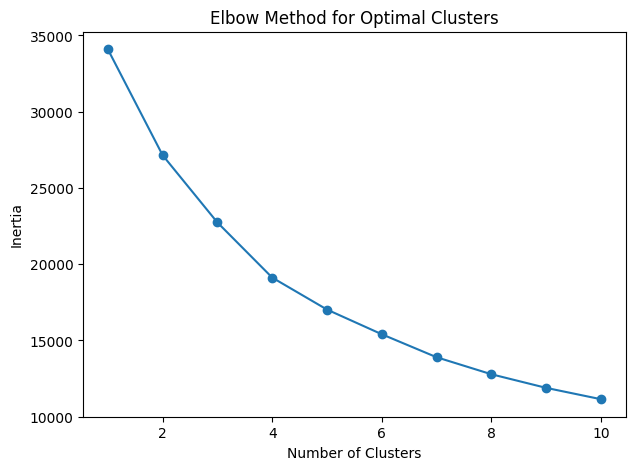

In [54]:
from sklearn.cluster import KMeans

inertia_values = []

K_range = range(1,11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_cluster_scaled)

    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(7,5))

plt.plot(
    K_range,
    inertia_values,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method for Optimal Clusters")

plt.show()

## K-Means Model Training

In [55]:
kmeans_model = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=100
)

clusters = kmeans_model.fit_predict(X_cluster_scaled)

df['Cluster'] = clusters

## Cluster Distribution

In [56]:
df['Cluster'].value_counts()

,count
Cluster,
0,3694
1,3125


## Cluster Visualization

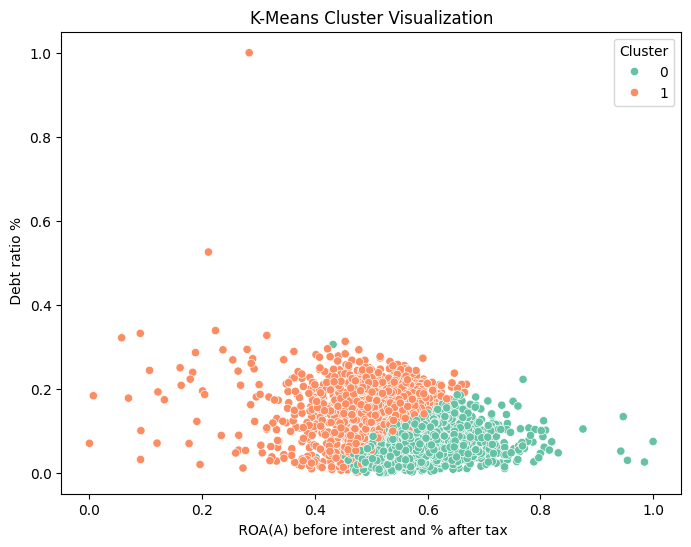

In [57]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df[' ROA(A) before interest and % after tax'],
    y=df[' Debt ratio %'],
    hue=df['Cluster'],
    palette='Set2'
)

plt.title("K-Means Cluster Visualization")

plt.show()

##Centroid Analysis

In [58]:
original_clustering_features = [
    ' ROA(A) before interest and % after tax',
    ' Debt ratio %',
    ' Cash flow rate',
    ' Retained Earnings to Total Assets',
    ' Liability to Equity'
]

centroids = pd.DataFrame(
    scaler_cluster.inverse_transform(
        kmeans_model.cluster_centers_
    ),
    columns=original_clustering_features
)

centroids

,ROA(A) before interest and % after tax,Debt ratio %,Cash flow rate,Retained Earnings to Total Assets,Liability to Equity
0,0.588835,0.080147,0.472825,0.944093,0.277407
1,0.522977,0.152152,0.461066,0.923688,0.283855


##Silhouette Score

In [59]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    X_cluster_scaled,
    clusters
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.2944333575404822


##K-Means Clustering Analysis

The K-Means clustering model was applied to identify hidden financial behavior patterns among companies using key financial indicators related to profitability, leverage, and financial stability.

Feature Selection and Scaling

The clustering analysis used several important financial variables, including:

ROA(A) before interest and % after tax

Debt ratio %

Cash Flow Rate

Retained Earnings to Total Assets

Liability to Equity

All variables were standardized using StandardScaler to ensure equal contribution during distance calculations.

###Elbow Method Analysis

The Elbow Method was used to determine the optimal number of clusters by analyzing inertia values across multiple cluster configurations.

Although the Elbow curve suggested that three or four clusters could be optimal, additional experiments showed that the extra clusters contained very few companies, sometimes only one company, indicating potential outliers rather than meaningful financial groups.

Therefore, the final K-Means model was implemented using two clusters to achieve better balance and more interpretable financial segmentation.

###Cluster Distribution

The clustering process produced two relatively balanced groups:

Cluster 0: 3694 companies

Cluster 1: 3125 companies

This indicates that the dataset can be divided into two major financial behavior patterns.

###Cluster Visualization and Interpretation

The cluster visualization showed noticeable separation between the two groups based on profitability and debt ratio indicators.

Cluster 0 generally included companies with:

Higher profitability

Lower debt levels

Better financial stability

Cluster 1 included companies with:

Lower profitability

Higher financial leverage

Greater financial risk

The centroid analysis further confirmed these differences in financial characteristics between the two clusters.

Silhouette Score Evaluation

The K-Means model achieved a silhouette score of approximately 0.29, indicating acceptable clustering quality and reasonable separation between company groups.

###Overall Interpretation

Overall, the K-Means model successfully identified meaningful financial company segments and revealed hidden financial behavior patterns that may support financial risk analysis and decision-making.

#Export Final Dataset for Power BI

This section prepares the final dataset that will be used in Power BI dashboards.

The exported dataset includes original financial indicators, model predictions, bankruptcy probability scores, risk levels, and cluster labels.

In [60]:
powerbi_dataset = df.copy()

powerbi_dataset['XGBoost_Prediction'] = xgb_model.predict(scaler.transform(X))

powerbi_dataset['XGBoost_Probability'] = xgb_model.predict_proba(scaler.transform(X))[:, 1]

powerbi_dataset['Cluster'] = df['Cluster']

###Description
This step prepares the final dataset for Power BI by combining original financial indicators, prediction probabilities, and cluster labels.

## Risk Level Classification

This step converts prediction probability scores into clear risk categories for dashboard analysis.

In [61]:
powerbi_dataset['Risk_Level'] = powerbi_dataset['XGBoost_Probability'].apply(
    lambda x: 'High Risk' if x >= 0.5 else 'Low Risk'
)

###Description

The risk level is created based on the XGBoost probability score. Companies with probability scores greater than or equal to 0.5 are classified as High Risk, while the remaining companies are classified as Low Risk.

## Export Dataset

In [62]:
powerbi_dataset.to_csv(
    'Taiwan_Bankruptcy_PowerBI_Dataset.csv',
    index=False
)

print("Power BI dataset exported successfully.")
print("Dataset Shape:", powerbi_dataset.shape)

Power BI dataset exported successfully.
Dataset Shape: (6819, 100)


The final dataset was exported as a CSV file for Power BI visualization and dashboard development.

##Download File

In [63]:
from google.colab import files

files.download('Taiwan_Bankruptcy_PowerBI_Dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Tools Research and Selection Effort

##Python

Python was used for data preprocessing, exploratory data analysis, statistical testing, machine learning modeling, and financial risk analysis.

Several Python libraries supported the analytical workflow, including:

Pandas for data manipulation and preprocessing
NumPy for numerical operations
Matplotlib and Seaborn for data visualization
Scikit-learn for machine learning preprocessing and evaluation
XGBoost for bankruptcy prediction modeling
TensorFlow/Keras for deep learning implementation
Imbalanced-learn (SMOTE) for handling class imbalance

Python was selected because of its strong support for financial analytics, machine learning, and predictive modeling tasks.

##Power BI

Power BI was used to develop interactive dashboards and business visualizations that support financial analysis and decision-making.

The dashboards included:

KPI cards
Financial risk indicators
Correlation analysis
Bankruptcy distribution analysis
Risk segmentation
Decision Support System (DSS) insights

Power BI was selected because of its interactive visualization capabilities and strong support for business intelligence applications.

##Microsoft Excel

Microsoft Excel was used during the initial stages of data inspection and preliminary dataset review.

Excel supported quick dataset exploration, manual verification, and basic financial data organization before advanced preprocessing and modeling.

##Google Colab

Google Colab was used as the main development environment for implementing machine learning and deep learning models.

It provided cloud-based computational resources and simplified the execution of Python notebooks, preprocessing tasks, and model training procedures.

##Integration

Together, these tools created a complete analytics workflow that combined:

data preprocessing,
exploratory analysis,
statistical testing,
predictive modeling,
and interactive business visualization.

This integration supported the development of a financial Decision Support System (DSS) for bankruptcy risk analysis and prediction.

#Project Deployment Effort – Use Case


##1. Dashboard Monitoring and Decision Support

The Power BI dashboards developed in this project allow financial managers and decision-makers to monitor:

Bankruptcy probability levels

Financial stability indicators

Debt exposure and leverage behavior

Operational performance and cash flow efficiency

Company risk categories and clustering groups

Managers can quickly identify financially risky companies, monitor financial health patterns, and support early bankruptcy risk detection.

##2. Bankruptcy Prediction Models

The predictive models were developed to forecast company bankruptcy risk using financial indicators and machine learning techniques.

###Business Uses:
Identify financially distressed companies early

Support financial risk assessment

Improve investment and lending decisions

Monitor high-risk companies more effectively

Reduce financial losses caused by unexpected bankruptcy

The XGBoost model achieved the strongest overall performance and provided better bankruptcy detection capability compared to the MLP Neural Network model.

##3. Financial Risk Segmentation – Clustering

K-Means clustering was applied to classify companies into groups based on profitability, debt structure, retained earnings, and financial stability behavior.

###Business Applications:

Segment companies into financial risk groups

Detect financially stable and financially vulnerable companies

Support portfolio risk monitoring

Improve strategic financial analysis

Assist in financial decision-making and company evaluation

Overall Business Value

##By combining dashboards, predictive analytics, and clustering analysis:

Dashboards answer: “What is happening financially?”

Prediction models answer: “Which companies are likely to face bankruptcy risk?”

Clustering answers: “Which financial company groups require attention?”

Together, these analytical approaches improve financial monitoring, bankruptcy risk assessment, strategic planning, and data-driven decision-making.

#Results

The results demonstrate that combining machine learning, clustering analysis, and Business Intelligence techniques provides valuable insights into financial risk behavior and bankruptcy prediction.

##Key Findings

The analysis revealed that bankruptcy risk is highly influenced by:

Debt ratio and borrowing dependency

Liability to equity structure

Operational efficiency

Cash flow performance

Retained earnings and profitability indicators

The dashboards also showed clear financial differences between Safe, Monitoring, and Critical companies.


## Exploratory and Statistical Analysis Findings

The exploratory and statistical analysis revealed several important financial relationships associated with bankruptcy risk.

The analysis showed that financially distressed companies generally exhibit:

Higher debt ratios and borrowing dependency

Lower profitability and operational efficiency

Weaker retained earnings and liquidity indicators

Correlation analysis and statistical testing also indicated meaningful relationships between leverage, profitability, cash flow behavior, and bankruptcy probability.

These findings supported the feature selection process and improved interpretation of the machine learning prediction results.


##Predictive Model Performance

The predictive models successfully identified financially risky companies with strong classification performance.

The XGBoost model achieved the best overall performance, particularly in:

Bankruptcy probability prediction

Risk separation capability

Handling imbalanced financial data

The model also demonstrated stronger predictive capability compared to the MLP Neural Network model.

## Clustering Outcomes

The clustering analysis identified two primary financial company groups using K-Means clustering:

Cluster 0: Financially stable companies

Cluster 1: Financially risky companies

The clustering process helped reveal hidden financial behavior patterns and improved company segmentation for financial monitoring purposes.

In addition, the predictive bankruptcy probabilities generated by the XGBoost model were used to classify companies into:

Safe companies

Monitoring-risk companies

Critical-risk companies

This additional categorization enhanced the Decision Support System by providing more detailed financial risk levels for business monitoring and analysis.


##Dashboard and Decision Support Outcomes

The Power BI dashboards successfully transformed predictive analytics into interactive financial decision support tools.

###The dashboards enabled:

Real-time bankruptcy risk monitoring

Financial KPI tracking

Company risk categorization

Financial behavior comparison

Interactive business analysis using slicers and filters

##Overall Impact

The project demonstrates how Artificial Intelligence, Machine Learning, Clustering, and Business Intelligence techniques can be integrated into a practical Decision Support System (DSS) for bankruptcy prediction and financial risk analysis.

###The final system supports:

Data-driven financial decision-making

Early bankruptcy detection

Financial risk monitoring

Strategic business analysis

Executive-level financial reporting

#Conclusion

This graduation project successfully demonstrated the integration of Business Intelligence, statistical analysis, machine learning, clustering, and data visualization techniques for bankruptcy prediction and financial risk analysis.

The project combined exploratory analysis, predictive modeling, clustering, and interactive Power BI dashboards to develop a practical Decision Support System (DSS) for financial monitoring and bankruptcy risk evaluation.

The analysis showed that financially distressed companies are generally associated with higher debt exposure, weaker profitability, and lower operational efficiency. Among the predictive models, XGBoost achieved the strongest overall performance in identifying financially risky companies.

The developed dashboards improved result interpretation through interactive visualization, KPI monitoring, company classification, and financial risk exploration. Overall, the project demonstrates how AI and Business Intelligence techniques can support data-driven financial decision-making and early bankruptcy risk detection.

# References

Altman, E. I. (1968). Financial ratios, discriminant analysis and the prediction of corporate bankruptcy. *Journal of Finance*, 23(4), 589–609.

Power, D. J. (2002). Decision Support Systems: Concepts and Resources for Managers.*Greenwood Publishing Group*.

Dua, D., & Graff, C. (2019). *UCI Machine Learning Repository*. University of California, Irvine, School of Information and Computer Sciences.

Han, J., Kamber, M., & Pei, J. (2012). Data Mining: Concepts and Techniques (3rd ed.). *Morgan Kaufmann*.

Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining.

Haykin, S. (2009). Neural Networks and Learning Machines (3rd ed.). *Pearson*.